# Towards a GIS system

In [ ]:
#| default_exp database

In [ ]:
#| export
import numpy as np
import sys
import os
import math
from math import radians, cos, sin, sqrt, atan2
import random

#data
from collections import namedtuple
from dataclasses import dataclass,  field, asdict
import json
from typing import List , Optional
from enum import Enum



In [ ]:
#| export
from dataclasses import dataclass
from typing import Optional

from datetime import datetime


In [ ]:
#| export
from fastcore.utils import *
from fasthtml.common import *
from fasthtml.jupyter import *
from fastlite import *
import fasthtml.components as fc
import httpx


In [ ]:
#| export
from importlib import resources
from pathlib import Path
import tempfile
import shutil
import sqlite3
from dataclasses import dataclass
from typing import Iterator
import numpy as np

In [ ]:
#| export
from HexMagic.climate import TerrainPatterns, DrainageBasins, Geology, TerraDemo, Terrain, GeoBounds, ClimatePreset, TerrainFactory
from HexMagic.primitives import MapCord, MapSize, MapRect, MapPath, Hex, HexGrid, HexWrapper, HexPosition, hexBackground, HexRegion, unique_windy_edge
from HexMagic.styles import StyleCSS, SVGBuilder

In [ ]:
#| export
from HexMagic.geology import River, Watershed

In [ ]:
#| export
import asyncio
from dataclasses import dataclass

In [ ]:
#!cat *.md

In [ ]:
#!cat ../llms.txt

## Helpers

In [ ]:
#| export
LoadResult = namedtuple('LoadResult', ['data', 'status', 'context'])
SaveResult = namedtuple('SaveResult', ['id', 'status', 'context'])

In [ ]:
#| export
@dataclass
class ChunkRef:
    """Reference to a chunk in the world - uses HexPosition for coordinates."""
    position: HexPosition  # Chunk's position in chunk-space (q+r+s=0)
    rings: int             # Hex rings per chunk
    
    @property
    def center_hex(self) -> HexPosition:
        """World hex coordinates of chunk center."""
        spacing = self.rings * 2
        return spacing * self.position
    
    @property
    def key(self) -> tuple[int, int, int]:
        """Hashable key for dict storage."""
        return (self.position.q, self.position.r, self.position.s)
    
    def __hash__(self):
        return hash(self.key)
    
    @classmethod
    def from_key(cls, key, chunk_rings: int) -> 'ChunkRef':
        if isinstance(key, tuple):
            q, r, s = key
        else:
            q, r, s = map(int, key.split(','))
        return cls(HexPosition(q, r, s), chunk_rings)




def chunk_to_world(chunk: ChunkRef, local_pos: HexPosition) -> HexPosition:
    """Map local hex position within chunk to world coordinates."""
    return chunk.center_hex + local_pos


def world_to_chunk(world_pos: HexPosition, chunk_rings: int) -> tuple[HexPosition, HexPosition]:
    """Map world position to (chunk_position, local_position_within_chunk)."""
    spacing = chunk_rings * 2
    
    chunk_q = world_pos.q // spacing
    chunk_r = world_pos.r // spacing
    chunk_s = -chunk_q - chunk_r
    
    chunk_pos = HexPosition(chunk_q, chunk_r, chunk_s)
    chunk_center = spacing * chunk_pos
    local_pos = world_pos - chunk_center
    
    return chunk_pos, local_pos


NameError: name 'dataclass' is not defined

In [ ]:
#| export



class ChunkedTerrainGenerator:
    """Generate and manage large terrains via chunking."""
    
    def __init__(self, storage: 'GeoStorage', 
                 coarse_radius: float = 100,
                 fine_radius: float = 10,
                 chunk_rings: int = 20,
                 halo_rings: int = 5):
        """
        Args:
            storage: GeoStorage for persistence
            coarse_radius: Hex radius for global overview map
            fine_radius: Hex radius for detailed chunks
            chunk_rings: Rings of hexes per chunk
            halo_rings: Extra rings for edge computation (weather, BFS)
        """
        self.storage = storage
        self.coarse_radius = coarse_radius
        self.fine_radius = fine_radius
        self.chunk_rings = chunk_rings
        self.halo_rings = halo_rings
        
        self.coarse_world_id = None
        self.chunk_world_ids = {}  # ChunkRef.key -> world_id
        self._plates = None
        self._coarse_terrain = None  # Cache for generation
    
    @property
    def scale(self) -> float:
        """Resolution scale factor between coarse and fine."""
        return self.coarse_radius / self.fine_radius
    
    # ─────────────────────────────────────────────────────────
    # Coordinate utilities
    # ─────────────────────────────────────────────────────────
    
    def world_to_chunk_ref(self, world_pos: HexPosition) -> ChunkRef:
        """Get the chunk containing a world position."""
        chunk_pos, _ = world_to_chunk(world_pos, self.chunk_rings)
        return ChunkRef(chunk_pos, self.chunk_rings)
    
    def local_to_world(self, chunk: ChunkRef, local_pos: HexPosition) -> HexPosition:
        """Map local chunk position to world coordinates."""
        return chunk_to_world(chunk, local_pos)
    
    def chunk_center_in_coarse(self, chunk: ChunkRef) -> HexPosition:
        """Get chunk center position in coarse grid coordinates."""
        world_center = chunk.center_hex
        coarse_q = int(world_center.q / self.scale)
        coarse_r = int(world_center.r / self.scale)
        return HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
    
    
    
    # ─────────────────────────────────────────────────────────
    # Phase 2: Chunk generation
    # ─────────────────────────────────────────────────────────
    
    def chunk_refs(self, max_ring: int) -> Iterator[ChunkRef]:
        """Yield ChunkRefs in spiral order from center outward."""
        for ring in range(max_ring + 1):
            for pos in HexPosition.origin().ring(ring):
                yield ChunkRef(pos, self.chunk_rings)
    
    def chunks_for_coarse(self, coarse_grid: HexGrid) -> Iterator[ChunkRef]:
        """Yield ChunkRefs covering the coarse grid extent."""
        spacing = self.chunk_rings * 2
        max_extent = max(coarse_grid.nRows, coarse_grid.nCols)
        max_chunk_ring = (max_extent // spacing) + 1
        return self.chunk_refs(max_chunk_ring)
    
    def generate_chunk(self, chunk: ChunkRef, coarse_terrain: Terrain = None) -> Terrain:
        """Generate detailed chunk by upsampling coarse region."""
        
        coarse = coarse_terrain or self._coarse_terrain
        if coarse is None:
            raise ValueError("No coarse terrain available")
        
        # Get chunk center in coarse coordinates
        coarse_center = self.chunk_center_in_coarse(chunk)
        
        # Calculate extraction radius in coarse hexes
        # Need enough to cover chunk + halo after upsampling
        coarse_rings = int((self.chunk_rings + self.halo_rings) / self.scale) + 2
        
        # Extract coarse region around chunk center
        extract_result = self.storage.extract_region(
            self.coarse_world_id,
            coarse_center.q, coarse_center.r, coarse_center.s,
            rings=coarse_rings,
            padding=1
        )
        
        if extract_result.status == 'extracted' and extract_result.data is not None:
            chunk_coarse = extract_result.data
        else:
            # Fallback: use full coarse terrain (less efficient)
            chunk_coarse = coarse
        
        # Upsample to fine resolution
        fine_terrain = chunk_coarse.upsample(scale=self.scale, method='bilinear')
        
        # Add deterministic local detail
        self._add_detail(fine_terrain, chunk)
        
        # Set chunk-specific metadata
        fine_terrain.climate = coarse.climate
        fine_terrain.geo = self._compute_chunk_bounds(chunk, coarse.geo)
        
        return fine_terrain
    
    def _add_detail(self, terrain: Terrain, chunk: ChunkRef):
        """Add fractal noise for local variation (deterministic per chunk)."""
        seed = hash(chunk.key) % (2**31)
        np.random.seed(seed)
        
        noise_scale = terrain.elevationDelta * 0.1
        terrain.elevations += np.random.uniform(
            -noise_scale, noise_scale, len(terrain.elevations)
        )
    
    def _compute_chunk_bounds(self, chunk: ChunkRef, world_geo: GeoBounds) -> GeoBounds:
        """Compute geographic bounds for a chunk."""
        if world_geo is None:
            return None
        
        # TODO: proper subdivision based on chunk position and size
        # For now, return world bounds (weather computation will still work)
        return world_geo
    
    # ─────────────────────────────────────────────────────────
    # Phase 3: Weather computation
    # ─────────────────────────────────────────────────────────
    
    def compute_chunk_weather(self, chunk_terrain: Terrain) -> Terrain:
        """Compute weather for a chunk."""
        if 'distance_to_coast' not in chunk_terrain.fields:
            chunk_terrain.compute_distance_from_coast()
        
        if chunk_terrain.climate:
            chunk_terrain.compute_weather()
        
        return chunk_terrain
    
    # ─────────────────────────────────────────────────────────
    # Phase 4: Save/Load
    # ─────────────────────────────────────────────────────────
    
    def save_chunk(self, terrain: Terrain, chunk: ChunkRef) -> int:
        """Save a chunk to storage."""
        p = chunk.position
        name = f"chunk_{p.q}_{p.r}_{p.s}"
        
        # Trim halo before saving
        core_terrain = self._trim_halo(terrain, chunk.rings)
        
        result = self.storage.save_world(core_terrain, name=name)
        self.chunk_world_ids[chunk.key] = result.id
        
        # Save weather if computed
        if 'temperature' in core_terrain.fields:
            self.storage.save_weather(core_terrain, result.id, season="annual")
        
        return result.id
    
    def load_chunk(self, chunk: ChunkRef) -> Terrain:
        """Load a chunk from storage."""
        world_id = self.chunk_world_ids.get(chunk.key)
        if world_id is None:
            return None
        result = self.storage.load_world(world_id)
        return result.data if result.status == 'loaded' else None
    
    def load_chunk_at(self, world_pos: HexPosition) -> Terrain:
        """Load the chunk containing a world position."""
        chunk = self.world_to_chunk_ref(world_pos)
        return self.load_chunk(chunk)
    
    def _trim_halo(self, terrain: Terrain, core_rings: int) -> Terrain:
        """Remove halo hexes, keep only core region."""
        grid = terrain.hexGrid
        
        # Find hexes within core_rings of center
        core_indices = set()
        for i in range(len(grid.hexes)):
            pos = grid.index_to_hexposition(i, origin_index=grid.middle)
            if abs(pos) <= core_rings:
                core_indices.add(i)
        
        if len(core_indices) == len(grid.hexes):
            return terrain  # No halo to trim
        
        # Create trimmed grid and terrain
        core_region = HexRegion(core_indices, grid)
        trimmed_grid, trimmed_region, mapper = core_region.crop_to_centered_grid(
            style=grid.style, 
            padding=0
        )
        
        # Build trimmed terrain
        trimmed = Terrain.__new__(Terrain)
        trimmed.hexGrid = trimmed_grid
        trimmed.elevations = np.zeros(len(trimmed_grid.hexes))
        trimmed.fields = {}
        trimmed.seaLevel = terrain.seaLevel
        trimmed.elevationDelta = terrain.elevationDelta
        trimmed.climate = terrain.climate
        trimmed.geo = terrain.geo
        trimmed.colorLevels = terrain.colorLevels
        trimmed.path = ""
        
        # Map data from old to new indices
        for new_idx in range(len(trimmed_grid.hexes)):
            old_idx = mapper(new_idx)
            if 0 <= old_idx < len(terrain.elevations):
                trimmed.elevations[new_idx] = terrain.elevations[old_idx]
                for field_name, field_data in terrain.fields.items():
                    if field_name not in trimmed.fields:
                        trimmed.fields[field_name] = np.zeros(len(trimmed_grid.hexes))
                    trimmed.fields[field_name][new_idx] = field_data[old_idx]
        
        return trimmed
    
    # ─────────────────────────────────────────────────────────
    # Index mapping
    # ─────────────────────────────────────────────────────────
    
    def create_chunk_mapper(self, chunk: ChunkRef, chunk_grid: HexGrid):
        """Create mapper from chunk grid index to world HexPosition."""
        def mapper(chunk_idx: int) -> HexPosition:
            local_pos = chunk_grid.index_to_hexposition(chunk_idx, origin_index=chunk_grid.middle)
            return chunk_to_world(chunk, local_pos)
        return mapper
    
    def create_world_to_chunk_mapper(self, chunk: ChunkRef, chunk_grid: HexGrid):
        """Create mapper from world HexPosition to chunk grid index."""
        def mapper(world_pos: HexPosition) -> int:
            local_pos = world_pos - chunk.center_hex
            return chunk_grid.hexposition_to_index(local_pos, origin_index=chunk_grid.middle)
        return mapper
    
    


In [ ]:
#| export
# ─────────────────────────────────────────────────────────
# Full pipeline
# ─────────────────────────────────────────────────────────
@patch
def generate_world(self:ChunkedTerrainGenerator, bounds: MapRect, 
                    num_plates: int = 15,
                    ocean_fraction: float = 0.4,
                    oceanic_sides: list = None,
                    compute_weather: bool = True,
                    compute_watersheds: bool = True,
                    progress_callback=None) -> int:
    """Generate complete chunked world.
    
    Args:
        bounds: World bounds
        num_plates: Number of tectonic plates
        ocean_fraction: Fraction of plates that are oceanic
        oceanic_sides: List of sides ['N','E','S','W'] that are ocean
        compute_weather: Whether to compute weather for each chunk
        progress_callback: Optional fn(current, total, message)
    
    Returns:
        coarse_world_id for reference
    """
    print("Phase 1: Generating coarse map...")
    coarse = self.generate_coarse(
        bounds, 
        num_plates=num_plates,
        ocean_fraction=ocean_fraction,
        oceanic_sides=oceanic_sides
    )
    
    chunks = list(self.chunks_for_coarse(coarse.hexGrid))
    total = len(chunks)
    
    print(f"Phase 2-4: Generating {total} chunks...")
    for i, chunk in enumerate(chunks):
        if progress_callback:
            progress_callback(i, total, f"Chunk {chunk.position}")
        elif i % 10 == 0:
            print(f"  {i+1}/{total}: {chunk.position}")
        
        # Generate
        chunk_terrain = self.generate_chunk(chunk, coarse)
        
        # Weather
        if compute_weather:
            self.compute_chunk_weather(chunk_terrain)

        
        # Save
        self.save_chunk(chunk_terrain, chunk)

        # Watersheds (after save, so world_id exists)
        if compute_watersheds and 'precipitation' in chunk_terrain.fields:
            basins = DrainageBasins(chunk_terrain)
            self.storage.save_watersheds(chunk_terrain, basins.sheds, self.chunk_world_ids[chunk.key])

    
    print(f"Done! Generated {total} chunks.")
    return self.coarse_world_id

# ─────────────────────────────────────────────────────────
    # Phase 1: Global coarse map
    # ─────────────────────────────────────────────────────────
    
    def generate_coarse(self, bounds: MapRect, 
                        num_plates: int = 15,
                        ocean_fraction: float = 0.4,
                        oceanic_sides: list = None,
                        name: str = "world_coarse",
                        max_lakes = 0
                        
                        ) -> Terrain:
        """Generate low-resolution global map for coastlines and plate structure."""
        
        terrain, plates = Terrain.fromSeeds(
            bounds,
            radius=self.coarse_radius,
            num_plates=num_plates,
            ocean_fraction=ocean_fraction,
            oceanic_sides=oceanic_sides or [],
            subdivisions=2,
        )
        
        # Compute distance from coast at coarse level
        terrain.compute_distance_from_coast()

        if max_lakes is not None:
            terrain.carve_to_ocean(num_lakes=max_lakes)
        
        # Save to storage
        result = self.storage.save_world(terrain, name=name)
        self.coarse_world_id = result.id
        self._plates = plates
        self._coarse_terrain = terrain  # Cache for chunk generation
        
        return terrain

In [ ]:
#| export
@patch
def generate_coarse(self:ChunkedTerrainGenerator, bounds: MapRect, 
                    num_plates: int = 15,
                    ocean_fraction: float = 0.4,
                    oceanic_sides: list = None,
                    name: str = "world_coarse",
                    max_lakes = 0,
                    climate: ClimatePreset = None,
                    geo: GeoBounds = None, 
                    compute_weather: bool = True  # NEW - default on
                    ) -> Terrain:
    """Generate low-resolution global map for coastlines and plate structure."""
    
    terrain, plates = Terrain.fromSeeds(
        bounds,
        radius=self.coarse_radius,
        num_plates=num_plates,
        ocean_fraction=ocean_fraction,
        oceanic_sides=oceanic_sides or [],
        subdivisions=2,elevation_scale=4,
    )
    
    terrain.compute_distance_from_coast()
    
    if max_lakes is not None:
        terrain.carve_to_ocean(num_lakes=max_lakes)
    
    # Set climate (required for weather)
    if climate is not None:
        terrain.climate = climate
    elif compute_weather:
        # Default to mediterranean or infer from geo bounds
        terrain.climate = TerrainPatterns(terrain).weatherPatterns()["temperate"]

    if geo is not None:
        terrain.geo = geo
    elif compute_weather:
        # Default synthetic bounds (e.g., mid-latitudes)
        terrain.geo = GeoBounds(lat_min=30, lat_max=50, lon_min=-10, lon_max=20)
    
    # Compute weather fields
    if compute_weather and terrain.climate:
        terrain.compute_weather()
    
    # Save to storage
    result = self.storage.save_world(terrain, name=name)
    self.coarse_world_id = result.id
    self._plates = plates
    self._coarse_terrain = terrain
    
    return terrain


NameError: name 'patch' is not defined

## Tables

In [ ]:
#| export
@dataclass  
class HexData:
    id: int = None
    world_id: int = 0
    q: int = 0
    r: int = 0
    s: int = 0
    grid_index: int = 0
    elevation: float = 0.0
    plate_id:int = -1
    latitude: Optional[float] = None
    longitude: Optional[float] = None
    distance_from_coast: Optional[float] = None
    watershed_id: Optional[int] = None  # NEW: FK to WatershedMeta
    modified: int = 0


NameError: name 'dataclass' is not defined

In [ ]:
#| export
@dataclass
class HexWeather:
    """Weather data for a hex at a point in time."""
    id: int = None
    world_id: int = 0
    q: int = 0
    r: int = 0
    s: int = 0
    # Core weather fields
    temperature: float = 0.0           # °C
    precipitation: float = 0.0         # mm/year
    humidity: Optional[float] = None   # %
    # Derived/computed fields
    climate_pet: Optional[float] = None          # potential evapotranspiration
    aridity_index: Optional[float] = None
    temp_seasonality: Optional[float] = None
    precip_seasonality: Optional[float] = None
    distance_from_coast: Optional[float] = None  # hex units
    # Temporal
    season: str = ""                   # e.g., "annual", "summer", "winter"
    modified: int = 0


In [ ]:
#| export
@dataclass
class WatershedMeta:
    """Metadata for a stored watershed."""
    id: int = None
    world_id: int = 0
    name: str = ""
    # Terminal hex (outlet)
    terminal_q: int = 0
    terminal_r: int = 0
    terminal_s: int = 0
    is_ocean: bool = True
    # Stats
    total_flow: float = 0.0
    area_hexes: int = 0
    # Encoded data
    river_tree: str = ""   # River.encode()
    style: str = ""        # StyleCSS.encode()
    created: int = 0
    modified: int = 0

In [ ]:
#| export


@dataclass
class TerrainWorld:
    """Metadata for a stored terrain."""
    id: int = None
    name: str = ""
    hex_radius: float = 25.0
    nrows: int = 0
    ncols: int = 0
    sea_level: float = 0.0
    elevation_delta: float = 90.0
    # Encoded extras (climate, geo bounds, etc)
    extras: str = ""
    created: int = 0
    modified: int = 0



In [ ]:
#| export
@dataclass
class User:
    username: str
    email: str
    password: str
    created: int  # Unix timestamp
    sessionID: str
    activeWorld: int # a link into world_id for world 
    id: int = None

## Main Storage

In [ ]:
#| export
class GeoStorage:

    def __init__(self, custom_path=None):
        path = GeoStorage.get_db_path(custom_path)
        self.path = path
        self.createDB()

    def createDB(self):
        db = database(self.path)
        self.db = db

        # Create tables using dataclasses
        db.create(TerrainWorld, pk='id', if_not_exists=True, transform=True)
        db.create(HexData, pk='id', if_not_exists=True, transform=True)
        db.create(User, pk='id', if_not_exists=True, transform=True)

        db.create(HexWeather, pk='id', if_not_exists=True, transform=True)

        # NEW: Watershed table
        db.create(WatershedMeta, pk='id', if_not_exists=True, transform=True)

        # After creating tables
        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_world ON hex_data(world_id)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_coords ON hex_data(world_id, q, r, s)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_grid ON hex_data(world_id, grid_index)")


        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_temporal ON hex_data(world_id, q, r, s, modified DESC)")

        

         # NEW: Index for watershed queries
        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_watershed ON hex_data(world_id, watershed_id)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_watershed_world ON watershed_meta(world_id)")

        # Indices for weather queries
        db.execute("CREATE INDEX IF NOT EXISTS idx_weather_world ON hex_weather(world_id)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_weather_coords ON hex_weather(world_id, q, r, s)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_weather_temporal ON hex_weather(world_id, q, r, s, modified DESC)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_weather_season ON hex_weather(world_id, season)")

        self.weather = db.t.hex_weather

        

        # Store table references using db.t notation
        self.users = db.t.user
        self.hexes = db.t.hex_data
        self.worlds = db.t.terrain_world
        self.watersheds = db.t.watershed_meta  # Add table reference

        
        
        # Populate templates (after tables exist)
        #self.populate_templates()


    @staticmethod
    def get_db_path(custom_path=None):
        """Get database path. Tries package data, falls back to user directory."""
        if custom_path:
            return custom_path
        
        # Try package data directory first
        try:
            db_dir = resources.files('HexMagic').joinpath('data/db')
            db_path = Path(db_dir) / 'hexmagic.db'
            # Test if writable
            db_path.parent.mkdir(parents=True, exist_ok=True)
            db_path.touch(exist_ok=True)
            return str(db_path)
        except (PermissionError, OSError):
            # Fallback to user directory
            data_dir = Path.home() / '.hexmagic' / 'data'
            data_dir.mkdir(parents=True, exist_ok=True)
            return str(data_dir / 'hexmagic.db')

    def __enter__(self):
        return self

    def __exit__(self, *args):
        self.db.close()

    
    @staticmethod
    def _get(obj, key):
        """Get attribute from dict or object."""
        return obj[key] if isinstance(obj, dict) else getattr(obj, key)

In [ ]:
#| export


#this might be something we don't export
@patch
def reset_database(self:GeoStorage):
    """Delete and recreate database. USE WITH CAUTION!"""
    db_path = Path(self.path)  # Convert string to Path
    
    if db_path.exists():
        db_path.unlink()

    self.createDB()



In [ ]:
#| export

@patch
def _latest_hex_subquery(self: GeoStorage, world_id: int, as_of: int = None) -> str:
    """SQL subquery for latest hex state, optionally at a point in time."""
    time_clause = f"AND modified <= {as_of}" if as_of else ""
    return f"""
        SELECT world_id, q, r, s, MAX(modified) as max_mod
        FROM hex_data
        WHERE world_id = {world_id} {time_clause}
        GROUP BY world_id, q, r, s
    """




In [ ]:
#| export
@patch
def query_hexes_latest(self: GeoStorage, world_id: int, as_of: int = None) -> list:
    """Get most recent version of each hex, optionally at a specific time."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    cursor = self.db.execute(f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
    """)
    
    # Get column names from cursor description
    cols = [d[0] for d in cursor.description]
    rows = [dict(zip(cols, row)) for row in cursor.fetchall()]
    
    return rows


In [ ]:
#| export
@patch
def update_hex(self: GeoStorage, world_id: int, q: int, r: int, s: int,
               elevation: float = None, latitude: float = None, longitude: float = None,
               distance_from_coast: float = None, grid_index: int = None) -> SaveResult:
    """Append a new state for a hex (temporal update)."""
    now = int(datetime.now().timestamp())
    
    record = {
        'world_id': world_id,
        'q': q, 'r': r, 's': s,
        'modified': now
    }
    
    # Get previous state to preserve unchanged fields
    prev = self.query_hexes_in_radius(world_id, q, r, s, radius=0)
    if prev:
        prev = prev[0]
        record['grid_index'] = grid_index if grid_index is not None else GeoStorage._get(prev, 'grid_index')
        record['elevation'] = elevation if elevation is not None else GeoStorage._get(prev, 'elevation')
        record['latitude'] = latitude if latitude is not None else GeoStorage._get(prev, 'latitude')
        record['longitude'] = longitude if longitude is not None else GeoStorage._get(prev, 'longitude')
        record['distance_from_coast'] = distance_from_coast if distance_from_coast is not None else GeoStorage._get(prev, 'distance_from_coast')
    else:
        record['grid_index'] = grid_index or 0
        record['elevation'] = elevation or 0.0
        record['latitude'] = latitude
        record['longitude'] = longitude
        record['distance_from_coast'] = distance_from_coast
    
    try:
        self.hexes.insert(record)
        return SaveResult(None, 'updated', f'hex ({q},{r},{s}) at {now}')
    except Exception as e:
        return SaveResult(None, 'error', str(e))


In [ ]:
#| export
@patch
def query_hexes_in_radius(self: GeoStorage, world_id: int,
                          center_q: int, center_r: int, center_s: int,
                          radius: int, as_of: int = None) -> list:
    """Query latest hexes within radius of a center position."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    rows = list(self.db.execute(f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.q BETWEEN ? AND ? AND h.r BETWEEN ? AND ?
    """, [
        center_q - radius, center_q + radius,
        center_r - radius, center_r + radius
    ]).fetchall())
    
    if not rows:
        return []
    
    # Hardcode column order to avoid cursor.description issue
    cols = ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 
        'plate_id', 'latitude', 'longitude', 'distance_from_coast', 
        'watershed_id', 'modified']
    
    rows = [dict(zip(cols, row)) for row in rows]
    
    # Filter to actual hex distance
    return [row for row in rows
            if max(abs(row['q'] - center_q), abs(row['r'] - center_r), abs(row['s'] - center_s)) <= radius]


NameError: name 'patch' is not defined

### World

#| export
@patch
def save_world(self: GeoStorage, terrain: Terrain, name: str = "") -> SaveResult:
    """Save terrain to database. Returns SaveResult(world_id, status, context)."""
    now = int(datetime.now().timestamp())
    
    grid = terrain.hexGrid
    
    # Build extras dict for non-field data
    extras = {}
    if terrain.geo:
        extras['geo'] = terrain.geo.encode() if hasattr(terrain.geo, 'encode') else str(terrain.geo)
    if terrain.climate:
        extras['climate'] = terrain.climate.encode() if hasattr(terrain.climate, 'encode') else str(terrain.climate)
    
    try:
        with self.db.conn:  # Transaction
            # Insert world metadata
            world_result = self.worlds.insert({
                'name': name or f"World_{now}",
                'hex_radius': grid.radius,
                'nrows': grid.nRows,
                'ncols': grid.nCols,
                'sea_level': terrain.seaLevel if isinstance(terrain.seaLevel, (int, float)) else 0.0,
                'elevation_delta': terrain.elevationDelta,
                'extras': json.dumps(extras),
                'created': now,
                'modified': now
            })
            
            world_id = world_result['id'] if isinstance(world_result, dict) else world_result
            
            # Insert hex data
            hex_records = []
            for idx, hex_obj in enumerate(grid.hexes):
                pos = grid.index_to_hexposition(idx)
                
                # Get lat/lon if geo bounds available
                lat, lon = None, None
                if terrain.geo and hasattr(terrain.geo, 'pixel_to_latlon'):
                    center = hex_obj.center
                    # Calculate grid pixel dimensions
                    width = grid.nCols * grid.radius * 1.5 + grid.radius
                    height = grid.nRows * grid.radius * math.sqrt(3) + grid.radius
                    lat, lon = terrain.geo.pixel_to_latlon(center.x, center.y, width, height)

                
                dist_coast = None
                if 'distance_to_ocean' in terrain.fields:
                    dist_coast = float(terrain.fields['distance_to_ocean'][idx])
                
                hex_records.append({
                    'world_id': world_id,
                    'q': pos.q,
                    'r': pos.r,
                    's': pos.s,
                    'grid_index': idx,
                    'elevation': float(terrain.elevations[idx]),
                    'latitude': lat,
                    'longitude': lon,
                    'distance_from_coast': dist_coast,
                    'modified': now
                })
            
            # Batch insert
            for record in hex_records:
                self.hexes.insert(record)
            
            return SaveResult(world_id, 'saved', f'{len(hex_records)} hexes')
    
    except Exception as e:
        return SaveResult(None, 'error', str(e))


In [ ]:
#| export
@patch
def save_world(self: GeoStorage, terrain: Terrain, name: str = "") -> SaveResult:
    """Save terrain to database, including plate_id if present."""
    now = int(datetime.now().timestamp())
    
    grid = terrain.hexGrid
    
    # Build extras dict
    extras = {}
    if terrain.geo:
        extras['geo'] = terrain.geo.encode() if hasattr(terrain.geo, 'encode') else str(terrain.geo)
    if terrain.climate:
        extras['climate'] = terrain.climate.encode() if hasattr(terrain.climate, 'encode') else str(terrain.climate)
    
    try:
        with self.db.conn:
            world_result = self.worlds.insert({
                'name': name or f"World_{now}",
                'hex_radius': grid.radius,
                'nrows': grid.nRows,
                'ncols': grid.nCols,
                'sea_level': terrain.seaLevel if isinstance(terrain.seaLevel, (int, float)) else 0.0,
                'elevation_delta': terrain.elevationDelta,
                'extras': json.dumps(extras),
                'created': now,
                'modified': now
            })
            
            world_id = world_result['id'] if isinstance(world_result, dict) else world_result
            
            # Check for plate_id field
            has_plates = 'plate_id' in terrain.fields
            
            for idx, hex_obj in enumerate(grid.hexes):
                pos = grid.index_to_hexposition(idx)
                
                lat, lon = None, None
                if terrain.geo and hasattr(terrain.geo, 'pixel_to_latlon'):
                    center = hex_obj.center
                    width = grid.nCols * grid.radius * 1.5 + grid.radius
                    height = grid.nRows * grid.radius * math.sqrt(3) + grid.radius
                    lat, lon = terrain.geo.pixel_to_latlon(center.x, center.y, width, height)
                
                dist_coast = None
                if 'distance_to_ocean' in terrain.fields:
                    dist_coast = float(terrain.fields['distance_to_ocean'][idx])
                
                # Include plate_id if available
                plate_id = int(terrain.fields['plate_id'][idx]) if has_plates else -1
                
                self.hexes.insert({
                    'world_id': world_id,
                    'q': pos.q, 'r': pos.r, 's': pos.s,
                    'grid_index': idx,
                    'elevation': float(terrain.elevations[idx]),
                    'plate_id': plate_id,
                    'latitude': lat,
                    'longitude': lon,
                    'distance_from_coast': dist_coast,
                    'modified': now
                })
            
            return SaveResult(world_id, 'saved', f'{len(grid.hexes)} hexes')
    
    except Exception as e:
        return SaveResult(None, 'error', str(e))


NameError: name 'patch' is not defined

In [ ]:
#| export
@patch
def load_world(self: GeoStorage, world_id: int, as_of: int = None) -> LoadResult:
    """Load terrain from database, including plate_id if present."""
    try:
        world = self.worlds[world_id]
        if not world:
            return LoadResult(None, 'not_found', f'World {world_id} not found')
        
        radius = GeoStorage._get(world, 'hex_radius')
        nrows = GeoStorage._get(world, 'nrows')
        ncols = GeoStorage._get(world, 'ncols')
        
        width = ncols * radius * 1.5 + radius
        height = nrows * radius * math.sqrt(3) + radius
        bounds = MapRect(MapCord(0, 0), MapSize(width, height))
        
        terrain = Terrain(bounds, radius=radius)
        terrain.hexGrid.nRows = nrows
        terrain.hexGrid.nCols = ncols
        terrain.hexGrid.adjustRadius(radius)
        terrain.elevations = np.zeros(len(terrain.hexGrid.hexes))
        terrain.elevationDelta = GeoStorage._get(world, 'elevation_delta')
        
        hex_rows = self.query_hexes_latest(world_id, as_of=as_of)
        
        # Check if any row has plate_id
        has_plates = any(GeoStorage._get(row, 'plate_id') is not None 
                        and GeoStorage._get(row, 'plate_id') >= 0 for row in hex_rows)
        
        if has_plates:
            terrain.fields['plate_id'] = np.full(len(terrain.elevations), -1, dtype=int)
        
        for row in hex_rows:
            idx = GeoStorage._get(row, 'grid_index')
            terrain.elevations[idx] = GeoStorage._get(row, 'elevation')
            
            # Restore plate_id
            plate_id = GeoStorage._get(row, 'plate_id')
            if has_plates and plate_id is not None:
                terrain.fields['plate_id'][idx] = plate_id
            
            dist = GeoStorage._get(row, 'distance_from_coast')
            if dist is not None:
                if 'distance_to_ocean' not in terrain.fields:
                    terrain.fields['distance_to_ocean'] = np.zeros(len(terrain.elevations))
                terrain.fields['distance_to_ocean'][idx] = dist
        
        extras_str = GeoStorage._get(world, 'extras')
        if extras_str:
            extras = json.loads(extras_str)
            # Could also restore geo/climate from extras here
        
        time_info = f" as of {as_of}" if as_of else ""
        return LoadResult(terrain, 'loaded', f'{len(hex_rows)} hexes{time_info}')
    
    except Exception as e:
        return LoadResult(None, 'error', str(e))


NameError: name 'patch' is not defined

### Region

@patch
def query_hexes_in_radius(self: GeoStorage, world_id: int,
                          center_q: int, center_r: int, center_s: int,
                          radius: int, as_of: int = None) -> list:
    """Query latest hexes within radius of a center position."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    cursor = self.db.execute(f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.q BETWEEN ? AND ? AND h.r BETWEEN ? AND ?
    """, [
        center_q - radius, center_q + radius,
        center_r - radius, center_r + radius
    ])
    
    # Convert to dicts like query_hexes_latest does
    cols = [d[0] for d in cursor.description]
    rows = [dict(zip(cols, row)) for row in cursor.fetchall()]
    
    # Filter to actual hex distance
    result = []
    for row in rows:
        dq = abs(GeoStorage._get(row, 'q') - center_q)
        dr = abs(GeoStorage._get(row, 'r') - center_r)
        ds = abs(GeoStorage._get(row, 's') - center_s)
        dist = max(dq, dr, ds)
        if dist <= radius:
            result.append(row)
    
    return result


In [ ]:
#| export
@patch
def extract_region(self: GeoStorage, world_id: int,
                   center_q: int, center_r: int, center_s: int,
                   rings: int, padding: int = 1, as_of: int = None) -> LoadResult:
    """Extract a centered region as a new Terrain.
    
    Returns LoadResult(terrain, status, context)
    """
    world = self.worlds[world_id]
    if not world:
        return LoadResult(None, 'not_found', f'World {world_id} not found')
    
    radius = GeoStorage._get(world, 'hex_radius')
    
    # Query hexes in region
    hex_rows = self.query_hexes_in_radius(world_id, center_q, center_r, center_s, rings, as_of=as_of)
    if not hex_rows:
        return LoadResult(None, 'empty', 'No hexes found in region')
    
    # Create centered grid
    total_rings = rings + padding
    grid = HexGrid.centered(radius=radius, rings=total_rings, style=StyleCSS("simple"))
    
    # Build terrain
    terrain = Terrain.__new__(Terrain)
    terrain.hexGrid = grid
    terrain.elevations = np.zeros(len(grid.hexes))
    terrain.fields = {}
    terrain.elevationDelta = GeoStorage._get(world, 'elevation_delta')
    terrain.seaLevel = GeoStorage._get(world, 'sea_level')
    terrain.climate = None
    terrain.path = ""
    terrain.colorLevels = None
    
    # Compute GeoBounds from extracted hexes
    lats = [GeoStorage._get(r, 'latitude') for r in hex_rows if GeoStorage._get(r, 'latitude') is not None]
    lons = [GeoStorage._get(r, 'longitude') for r in hex_rows if GeoStorage._get(r, 'longitude') is not None]
    
    if lats and lons:
        terrain.geo = GeoBounds(
            lat_min=min(lats), lat_max=max(lats),
            lon_min=min(lons), lon_max=max(lons)
        )

    else:
        terrain.geo = None
    
    # Map DB rows to centered grid
    filled = 0
    
    for row in hex_rows:
        # Position relative to query center
        q = GeoStorage._get(row, 'q') - center_q
        r = GeoStorage._get(row, 'r') - center_r
        s = GeoStorage._get(row, 's') - center_s
        rel_pos = HexPosition(q, r, s)
        
        # Map to centered grid
        new_idx = grid.hexposition_to_index(rel_pos, origin_index=grid.middle)
        if 0 <= new_idx < len(grid.hexes):
            terrain.elevations[new_idx] = GeoStorage._get(row, 'elevation')
            
            dist = GeoStorage._get(row, 'distance_from_coast')
            if dist is not None:
                if 'distance_to_ocean' not in terrain.fields:
                    terrain.fields['distance_to_ocean'] = np.zeros(len(grid.hexes))
                terrain.fields['distance_to_ocean'][new_idx] = dist
            
            filled += 1
    
    return LoadResult(terrain, 'extracted', f'{filled}/{len(hex_rows)} hexes mapped')


In [ ]:
#| export
def create_region_coord_mapper(center_q: int, center_r: int, center_s: int, 
                                extracted_grid: HexGrid) -> callable:
    """Create mapper from extracted region index to original world (q,r,s).
    
    Args:
        center_q, center_r, center_s: The center point used for extraction
        extracted_grid: The centered grid from extract_region
    
    Returns:
        Function: new_idx -> (q, r, s) tuple in original world coords
    """
    def mapper(new_idx: int) -> tuple[int, int, int]:
        # Get position relative to extracted grid's center
        rel_pos = extracted_grid.index_to_hexposition(new_idx, origin_index=extracted_grid.middle)
        # Add back the world center offset
        return (center_q + rel_pos.q, center_r + rel_pos.r, center_s + rel_pos.s)
    
    return mapper


In [ ]:
#| export
@patch
def create_region_index_mapper(self: GeoStorage, world_id: int,
                                center_q: int, center_r: int, center_s: int,
                                extracted_grid: HexGrid) -> callable:
    """Create mapper from extracted region index to original world grid_index.
    
    Args:
        world_id: The source world
        center_q, center_r, center_s: The center point used for extraction
        extracted_grid: The centered grid from extract_region
    
    Returns:
        Function: new_idx -> original_grid_index (or -1 if not in world)
    """
    # Build lookup dict from DB (q,r,s) -> grid_index
    hex_rows = list(self.hexes.rows_where('world_id = ?', [world_id]))
    coord_to_idx = {
        (GeoStorage._get(r, 'q'), GeoStorage._get(r, 'r'), GeoStorage._get(r, 's')): 
        GeoStorage._get(r, 'grid_index')
        for r in hex_rows
    }
    
    def mapper(new_idx: int) -> int:
        rel_pos = extracted_grid.index_to_hexposition(new_idx, origin_index=extracted_grid.middle)
        world_coords = (center_q + rel_pos.q, center_r + rel_pos.r, center_s + rel_pos.s)
        return coord_to_idx.get(world_coords, -1)
    
    return mapper


### Weather

In [ ]:
#| export
@patch
def save_weather(self: GeoStorage, terrain: Terrain, world_id: int, 
                 season: str = "annual") -> SaveResult:
    """Save weather data for a terrain to database.
    
    Args:
        terrain: Terrain with weather fields computed
        world_id: World ID to associate weather with
        season: Season identifier (e.g., "annual", "summer", "winter")
    
    Returns:
        SaveResult(count, status, context)
    """
    now = int(datetime.now().timestamp())
    grid = terrain.hexGrid
    
    # Check for required weather fields
    if 'temperature' not in terrain.fields or 'precipitation' not in terrain.fields:
        return SaveResult(None, 'error', 'Missing temperature or precipitation fields')
    
    try:
        with self.db.conn:
            records = []
            for idx in range(len(terrain.elevations)):
                pos = grid.index_to_hexposition(idx)
                
                record = {
                    'world_id': world_id,
                    'q': pos.q,
                    'r': pos.r,
                    's': pos.s,
                    'temperature': float(terrain.fields['temperature'][idx]),
                    'precipitation': float(terrain.fields['precipitation'][idx]),
                    'humidity': float(terrain.fields['humidity'][idx]) if 'humidity' in terrain.fields else None,
                    'climate_pet': float(terrain.fields['climate_pet'][idx]) if 'climate_pet' in terrain.fields else None,
                    'aridity_index': float(terrain.fields['aridity_index'][idx]) if 'aridity_index' in terrain.fields else None,
                    'temp_seasonality': float(terrain.fields['temp_seasonality'][idx]) if 'temp_seasonality' in terrain.fields else None,
                    'precip_seasonality': float(terrain.fields['precip_seasonality'][idx]) if 'precip_seasonality' in terrain.fields else None,
                    'distance_from_coast': float(terrain.fields['distance_to_coast'][idx]) if 'distance_to_coast' in terrain.fields else None,
                    'season': season,
                    'modified': now
                }
                records.append(record)
            
            for record in records:
                self.weather.insert(record)
            
            return SaveResult(len(records), 'saved', f'{len(records)} weather records for season={season}')
    
    except Exception as e:
        return SaveResult(None, 'error', str(e))




In [ ]:
#| export

@patch
def load_weather(self: GeoStorage, world_id: int, terrain: Terrain,
                 season: str = "annual", as_of: int = None) -> LoadResult:
    """Load weather data into a terrain's fields.
    
    Args:
        world_id: World ID to load weather for
        terrain: Terrain to populate with weather fields
        season: Season to load
        as_of: Optional timestamp for temporal query
    
    Returns:
        LoadResult(terrain, status, context)
    """
    try:
        # Build temporal subquery
        time_clause = f"AND modified <= {as_of}" if as_of else ""
        
        cursor = self.db.execute(f"""
            SELECT hw.* FROM hex_weather hw
            INNER JOIN (
                SELECT world_id, q, r, s, MAX(modified) as max_mod
                FROM hex_weather
                WHERE world_id = ? AND season = ? {time_clause}
                GROUP BY world_id, q, r, s
            ) latest 
                ON hw.world_id = latest.world_id 
                AND hw.q = latest.q AND hw.r = latest.r AND hw.s = latest.s
                AND hw.modified = latest.max_mod
            WHERE hw.season = ?
        """, [world_id, season, season])
        
        cols = [d[0] for d in cursor.description]
        rows = [dict(zip(cols, row)) for row in cursor.fetchall()]
        
        if not rows:
            return LoadResult(terrain, 'empty', f'No weather data for world={world_id}, season={season}')
        
        # Initialize field arrays
        n_hexes = len(terrain.elevations)
        terrain.fields['temperature'] = np.zeros(n_hexes)
        terrain.fields['precipitation'] = np.zeros(n_hexes)
        terrain.fields['humidity'] = np.zeros(n_hexes)
        terrain.fields['climate_pet'] = np.zeros(n_hexes)
        terrain.fields['aridity_index'] = np.zeros(n_hexes)
        terrain.fields['temp_seasonality'] = np.zeros(n_hexes)
        terrain.fields['precip_seasonality'] = np.zeros(n_hexes)
        terrain.fields['distance_to_coast'] = np.zeros(n_hexes)
        
        # Map weather data to terrain indices
        grid = terrain.hexGrid
        filled = 0
        
        for row in rows:
            pos = HexPosition(row['q'], row['r'], row['s'])
            idx = grid.hexposition_to_index(pos)
            
            if 0 <= idx < n_hexes:
                terrain.fields['temperature'][idx] = row['temperature'] or 0.0
                terrain.fields['precipitation'][idx] = row['precipitation'] or 0.0
                if row['humidity'] is not None:
                    terrain.fields['humidity'][idx] = row['humidity']
                if row['climate_pet'] is not None:
                    terrain.fields['climate_pet'][idx] = row['climate_pet']
                if row['aridity_index'] is not None:
                    terrain.fields['aridity_index'][idx] = row['aridity_index']
                if row['temp_seasonality'] is not None:
                    terrain.fields['temp_seasonality'][idx] = row['temp_seasonality']
                if row['precip_seasonality'] is not None:
                    terrain.fields['precip_seasonality'][idx] = row['precip_seasonality']
                if row['distance_from_coast'] is not None:
                    terrain.fields['distance_to_coast'][idx] = row['distance_from_coast']
                filled += 1
        
        time_info = f" as of {as_of}" if as_of else ""
        return LoadResult(terrain, 'loaded', f'{filled} weather records for season={season}{time_info}')
    
    except Exception as e:
        return LoadResult(None, 'error', str(e))

### watershed

In [ ]:
#| export
@patch
def save_watersheds(self: GeoStorage, terrain: Terrain, 
                    watersheds: list, world_id: int) -> SaveResult:
    """Save watersheds and assign watershed_id to hexes.
    
    Args:
        terrain: Terrain with computed watersheds
        watersheds: List of Watershed objects
        world_id: World to associate with
    
    Returns:
        SaveResult(count, status, context)
    """
    now = int(datetime.now().timestamp())
    grid = terrain.hexGrid
    
    try:
        with self.db.conn:
            
            
            # Build hex -> watershed mapping
            hex_to_watershed = {}
            
            for i, watershed in enumerate(watersheds):
                # Get terminal position
                terminal_idx = watershed.terminal_hex
                if terminal_idx is not None:
                    terminal_pos = grid.index_to_hexposition(terminal_idx)
                else:
                    terminal_pos = HexPosition(0, 0, 0)
                
                # Calculate stats
                flows = watershed.calculate_flow()
                max_flow = max(flows.values()) if flows else 0
                
                # Save watershed metadata
                ws_record = {
                    'world_id': world_id,
                    'name': f"watershed_{i}",
                    'terminal_q': terminal_pos.q,
                    'terminal_r': terminal_pos.r,
                    'terminal_s': terminal_pos.s,
                    'is_ocean': watershed.is_ocean,
                    'total_flow': max_flow,
                    'area_hexes': len(watershed.region.hexes),
                    'river_tree': watershed.tributary.encode(),
                    'style': watershed.style.encode() if hasattr(watershed.style, 'encode') else str(watershed.style),
                    'created': now,
                    'modified': now
                }
                
                result = self.watersheds.insert(ws_record)
                ws_id = result['id'] if isinstance(result, dict) else result
                
                # Map hexes to this watershed
                for hex_idx in watershed.region.hexes:
                    hex_to_watershed[hex_idx] = ws_id
            
            # Update hex_data with watershed_id
            for hex_idx, ws_id in hex_to_watershed.items():
                pos = grid.index_to_hexposition(hex_idx)
                
                # Insert new record with watershed_id
                self.hexes.insert({
                    'world_id': world_id,
                    'q': pos.q,
                    'r': pos.r,
                    's': pos.s,
                    'grid_index': hex_idx,
                    'elevation': float(terrain.elevations[hex_idx]),
                    'watershed_id': ws_id,
                    'modified': now
                })
            
            return SaveResult(len(watersheds), 'saved', 
                            f'{len(watersheds)} watersheds, {len(hex_to_watershed)} hexes assigned')
    
    except Exception as e:
        return SaveResult(None, 'error', str(e))





@patch
def query_watershed_hexes(self: GeoStorage, world_id: int, 
                          watershed_id: int) -> list:
    """Get all hexes belonging to a specific watershed."""
    cursor = self.db.execute("""
        SELECT h.* FROM hex_data h
        INNER JOIN (
            SELECT world_id, q, r, s, MAX(modified) as max_mod
            FROM hex_data
            WHERE world_id = ? AND watershed_id = ?
            GROUP BY world_id, q, r, s
        ) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.watershed_id = ?
    """, [world_id, watershed_id, watershed_id])
    
    cols = [d[0] for d in cursor.description]
    return [dict(zip(cols, row)) for row in cursor.fetchall()]


In [ ]:
#| export
@patch
def load_watersheds(self: GeoStorage, world_id: int, 
                    terrain: Terrain) -> LoadResult:
    """Load watersheds for a world.
    
    Args:
        world_id: World to load from
        terrain: Terrain to attach watersheds to
    
    Returns:
        LoadResult(watersheds_list, status, context)
    """
    try:
        # Query watershed metadata
        ws_rows = list(self.watersheds.rows_where(
    'world_id = ?', [world_id]
))
        
        
        if not ws_rows:
            return LoadResult([], 'empty', f'No watersheds for world {world_id}')
        
        # Query hex -> watershed mapping
        hex_rows = self.query_hexes_latest(world_id)
        
        # Group hexes by watershed_id
        ws_hexes = {}  # watershed_id -> set of hex indices
        for row in hex_rows:
            ws_id = row.get('watershed_id')
            if ws_id is not None:
                if ws_id not in ws_hexes:
                    ws_hexes[ws_id] = set()
                ws_hexes[ws_id].add(row['grid_index'])
        
        # Reconstruct Watershed objects
        watersheds = []
        for ws_row in ws_rows:
            ws_id = ws_row['id']
            
            
            # Get hexes for this watershed
            hexes = ws_hexes.get(ws_id, set())
            region = HexRegion(hexes=hexes, hexGrid=terrain.hexGrid)
            
            # Decode river
            river_str = ws_row['river_tree']
            river = River.decode(river_str, terrain) if river_str else River(terrain)
            
            # Decode style
            style_str = ws_row['style']
            if style_str:
                style = StyleCSS.decode(style_str)
            else:
                style = StyleCSS(f"ws_{ws_id}", fill="#cccccc")
            
            watershed = Watershed(
                region=region,
                tributary=river,
                style=style
            )
            watersheds.append(watershed)
        
        return LoadResult(watersheds, 'loaded', f'{len(watersheds)} watersheds')
    
    except Exception as e:
        return LoadResult(None, 'error', str(e))

I got the following error. I am trying to make plate id persisenct can you give me better load and save world



Assistant: 418

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

You're right. The issue is that load_chunk returns terrain from storage, but save_world/load_world likely doesn't preserve the fields dict (including plate_id). So when we load a previously saved chunk, fields is empty or missing plate_id.

Quick fix - always generate fresh in the pathfinding test (skip load):
Copied!

# In hpa_pathfind_v2, replace:
terrain = gen.load_chunk(chunk_ref)
if terrain is None:
    terrain = gen.generate_chunk(chunk_ref)
    gen.save_chunk(terrain, chunk_ref)

# With just:
terrain = gen.generate_chunk(chunk_ref)

Proper fix - ensure GeoStorage.save_world and load_world round-trip the fields dict. Check if save_world stores fields like:
Copied!

# In save_world, after saving elevations:
for field_name, field_data in terrain.fields.items():
    for idx, value in enumerate(field_data):
        # Store in hex row or separate fields table
        ...

And in load_world:
Copied!

# Reconstruct fields from stored data
terrain.fields = {}
for field_name in stored_field_names:
    terrain.fields[field_name] = np.array([...])

What does your current save_world/load_world do with terrain.fields?


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The issue is that `save_world` saves `plate_id` to the DB, but `load_world` doesn't restore it to `terrain.fields`. Here's the fix:

```python
@patch
def load_world(self: GeoStorage, world_id: int, as_of: int = None) -> LoadResult:
    """Load terrain from database, including plate_id if present."""
    try:
        world = self.worlds[world_id]
        if not world:
            return LoadResult(None, 'not_found', f'World {world_id} not found')
        
        radius = GeoStorage._get(world, 'hex_radius')
        nrows = GeoStorage._get(world, 'nrows')
        ncols = GeoStorage._get(world, 'ncols')
        
        width = ncols * radius * 1.5 + radius
        height = nrows * radius * math.sqrt(3) + radius
        bounds = MapRect(MapCord(0, 0), MapSize(width, height))
        
        terrain = Terrain(bounds, radius=radius)
        terrain.hexGrid.nRows = nrows
        terrain.hexGrid.nCols = ncols
        terrain.hexGrid.adjustRadius(radius)
        terrain.elevations = np.zeros(len(terrain.hexGrid.hexes))
        terrain.elevationDelta = GeoStorage._get(world, 'elevation_delta')
        
        hex_rows = self.query_hexes_latest(world_id, as_of=as_of)
        
        # Check if any row has plate_id
        has_plates = any(GeoStorage._get(row, 'plate_id') is not None 
                        and GeoStorage._get(row, 'plate_id') >= 0 for row in hex_rows)
        
        if has_plates:
            terrain.fields['plate_id'] = np.full(len(terrain.elevations), -1, dtype=int)
        
        for row in hex_rows:
            idx = GeoStorage._get(row, 'grid_index')
            terrain.elevations[idx] = GeoStorage._get(row, 'elevation')
            
            # Restore plate_id
            plate_id = GeoStorage._get(row, 'plate_id')
            if has_plates and plate_id is not None:
                terrain.fields['plate_id'][idx] = plate_id
            
            dist = GeoStorage._get(row, 'distance_from_coast')
            if dist is not None:
                if 'distance_to_ocean' not in terrain.fields:
                    terrain.fields['distance_to_ocean'] = np.zeros(len(terrain.elevations))
                terrain.fields['distance_to_ocean'][idx] = dist
        
        extras_str = GeoStorage._get(world, 'extras')
        if extras_str:
            extras = json.loads(extras_str)
            # Could also restore geo/climate from extras here
        
        time_info = f" as of {as_of}" if as_of else ""
        return LoadResult(terrain, 'loaded', f'{len(hex_rows)} hexes{time_info}')
    
    except Exception as e:
        return LoadResult(None, 'error', str(e))
```

Also need to update `query_hexes_in_radius` to include `plate_id` in the column list:

```python
# In query_hexes_in_radius, update the cols list:
cols = ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 'plate_id',
        'latitude', 'longitude', 'distance_from_coast', 'watershed_id', 'modified']
```

## Debugger

In [ ]:
#| export
class GeoStorageDebugger:
    """Test harness for HexServer with automatic cleanup."""
    
    def __init__(self, keep_on_error=False):
        """
        Args:
            keep_on_error: If True, preserve database when tests fail
        """
        self.temp_dir = tempfile.mkdtemp(prefix='hexmagic_test_')
        self.db_path = os.path.join(self.temp_dir, 'test.db')
        self.server = GeoStorage(custom_path=self.db_path)
        self.keep_on_error = keep_on_error
        self.failed = False
        
    def preserve_db(self, test_name):
        """Copy database to inspection directory."""
        inspect_dir = Path.home() / '.hexmagic' / 'test_failures'
        inspect_dir.mkdir(parents=True, exist_ok=True)
        
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        dest = inspect_dir / f"{test_name}_{timestamp}.db"
        
        shutil.copy2(self.db_path, dest)
        print(f"⚠ Database preserved at: {dest}")
        
    def close(self):
        """Clean up test database."""
        self.server.db.close()
        
        if not self.failed or not self.keep_on_error:
            shutil.rmtree(self.temp_dir)
            print("✓ Test database cleaned up")
        else:
            print(f"⚠ Test database kept at: {self.temp_dir}")
            
    def __enter__(self):
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        if exc_type is not None:
            self.failed = True
        self.close()


In [ ]:
#| export
@patch
def test_save_load_terrain(self: GeoStorageDebugger):
    """Test saving and loading a terrain."""
    td = TerraDemo()
    terrain = td.aussie_map()
    
    # Save
    save_result = self.server.save_world(terrain, name="Australia Test")
    assert save_result.status == 'saved', f"Save failed: {save_result.status} - {save_result.context}"
    print(f"✓ Saved world {save_result.id}: {save_result.context}")
    
    # Load
    load_result = self.server.load_world(save_result.id)
    assert load_result.status == 'loaded', f"Load failed: {load_result.status} - {load_result.context}"
    print(f"✓ Loaded world: {load_result.context}")
    
    # Verify
    loaded = load_result.data
    assert len(loaded.elevations) == len(terrain.elevations), "Elevation count mismatch"
    assert np.allclose(loaded.elevations, terrain.elevations), "Elevation values don't match"
    print(f"✓ Elevations match ({len(loaded.elevations)} hexes)")


In [ ]:
#| export
@patch
def test_query_radius(self: GeoStorageDebugger):
    """Test querying hexes by position and radius."""
    td = TerraDemo()
    terrain = td.aussie_map()
    
    # Save
    save_result = self.server.save_world(terrain, name="Query Test")
    assert save_result.status == 'saved'
    
    # Query center region (q=0, r=0, s=0 with radius 5)
    hexes = self.server.query_hexes_in_radius(save_result.id, 0, 0, 0, radius=5)
    
    # Should get some hexes (exact count depends on map)
    print(f"✓ Found {len(hexes)} hexes within radius 5 of origin")
    assert len(hexes) > 0, "Expected some hexes near origin"


In [ ]:
#| export
@patch
def test_extract_region(self: GeoStorageDebugger):
    """Test extracting a centered region."""
    td = TerraDemo()
    terrain = td.aussie_map()
    
    # Save full terrain
    save_result = self.server.save_world(terrain, name="Extract Test")
    assert save_result.status == 'saved'
    
    # Extract a region around origin
    result = self.server.extract_region(save_result.id, 0, 0, 0, rings=10)
    assert result.status == 'extracted', f"Extract failed: {result.context}"
    
    extracted = result.data
    print(f"✓ Extracted region: {result.context}")
    print(f"  Grid size: {len(extracted.hexGrid.hexes)} hexes")
    
    # Verify it's centered
    assert extracted.hexGrid.middle is not None
    print(f"  Center index: {extracted.hexGrid.middle}")


In [ ]:
#| export
@patch
def test_region_mappers(self: GeoStorageDebugger):
    """Test that region mappers correctly translate indices."""
    td = TerraDemo()
    terrain = td.aussie_map()
    
    save_result = self.server.save_world(terrain, name="Mapper Test")
    assert save_result.status == 'saved'
    
    center_q, center_r, center_s = 5, -3, -2
    result = self.server.extract_region(save_result.id, center_q, center_r, center_s, rings=5)
    assert result.status == 'extracted'
    
    extracted = result.data
    grid = extracted.hexGrid
    
    # Test coord mapper
    coord_mapper = create_region_coord_mapper(center_q, center_r, center_s, grid)
    
    # Center of extracted grid should map back to query center
    center_coords = coord_mapper(grid.middle)
    assert center_coords == (center_q, center_r, center_s), f"Center mismatch: {center_coords}"
    print(f"✓ Coord mapper: center maps to {center_coords}")
    
    # Test index mapper  
    idx_mapper = self.server.create_region_index_mapper(
        save_result.id, center_q, center_r, center_s, grid
    )
    
    # Verify some mappings
    valid_count = sum(1 for i in range(len(grid.hexes)) if idx_mapper(i) >= 0)
    print(f"✓ Index mapper: {valid_count}/{len(grid.hexes)} indices map to original")


In [ ]:
#| export
@patch
def test_save_load_weather(self: GeoStorageDebugger):
    """Test saving and loading weather data."""
    # Use sfTerr which already has weather fields computed
    with open('sf_coast_weather.txt') as f:
        terrain = Terrain.decode(f.read())
    
    # First save the world (need world_id for weather)
    save_world_result = self.server.save_world(terrain, name="SF Weather Test")
    assert save_world_result.status == 'saved', f"World save failed: {save_world_result.context}"
    world_id = save_world_result.id
    print(f"✓ Saved world {world_id}")
    
    # Save weather
    save_weather_result = self.server.save_weather(terrain, world_id, season="annual")
    assert save_weather_result.status == 'saved', f"Weather save failed: {save_weather_result.context}"
    print(f"✓ Saved weather: {save_weather_result.context}")
    
    # Load world (without weather)
    load_world_result = self.server.load_world(world_id)
    assert load_world_result.status == 'loaded'
    loaded_terrain = load_world_result.data
    
    # Verify no weather fields yet
    assert 'temperature' not in loaded_terrain.fields or loaded_terrain.fields['temperature'].sum() == 0
    print(f"✓ Loaded world without weather fields")
    
    # Load weather into terrain
    load_weather_result = self.server.load_weather(world_id, loaded_terrain, season="annual")
    assert load_weather_result.status == 'loaded', f"Weather load failed: {load_weather_result.context}"
    print(f"✓ Loaded weather: {load_weather_result.context}")
    
    # Verify weather data matches
    assert np.allclose(loaded_terrain.fields['temperature'], terrain.fields['temperature']), "Temperature mismatch"
    assert np.allclose(loaded_terrain.fields['precipitation'], terrain.fields['precipitation']), "Precipitation mismatch"
    print(f"✓ Weather data matches original")
    
    # Test seasonal storage - save summer data with modified temps
    terrain.fields['temperature'] = terrain.fields['temperature'] + 5  # Summer is warmer
    save_summer = self.server.save_weather(terrain, world_id, season="summer")
    assert save_summer.status == 'saved'
    print(f"✓ Saved summer weather")
    
    # Load summer and verify it's different from annual
    load_summer = self.server.load_weather(world_id, loaded_terrain, season="summer")
    assert load_summer.status == 'loaded'
    assert loaded_terrain.fields['temperature'].mean() > terrain.fields['temperature'].mean() - 5 + 4  # Should be ~5°C warmer
    print(f"✓ Summer temperatures correctly loaded (warmer than annual)")


In [ ]:
#| export
@patch
def test_chunked_terrain_generator(self: GeoStorageDebugger):
    """Test chunked terrain generation pipeline."""
    generator = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_radius=50,      # Large hexes for overview
        fine_radius=10,        # Detailed hexes for chunks
        chunk_rings=8,         # Small chunks for testing
        halo_rings=2
    )
    
    # Phase 1: Generate coarse map
    bounds = MapRect(MapCord(0, 0), MapSize(800, 600))
    coarse = generator.generate_coarse(
        bounds,
        num_plates=5,
        ocean_fraction=0.3,
        name="chunked_test_coarse"
    )
    
    assert generator.coarse_world_id is not None, "Coarse world not saved"
    assert len(coarse.elevations) > 0, "Coarse terrain has no hexes"
    print(f"✓ Generated coarse map: {len(coarse.hexGrid.hexes)} hexes, world_id={generator.coarse_world_id}")
    
    # Phase 2: Generate a single chunk at origin
    origin_chunk = ChunkRef(HexPosition(0, 0, 0), generator.chunk_rings)
    chunk_terrain = generator.generate_chunk(origin_chunk, coarse)
    
    assert len(chunk_terrain.elevations) > 0, "Chunk terrain empty"
    assert generator.scale == 5.0, f"Expected scale 5.0, got {generator.scale}"
    print(f"✓ Generated chunk at origin: {len(chunk_terrain.hexGrid.hexes)} hexes")
    
    # Phase 3: Save chunk
    chunk_id = generator.save_chunk(chunk_terrain, origin_chunk)
    assert chunk_id is not None, "Chunk not saved"
    assert origin_chunk.key in generator.chunk_world_ids
    print(f"✓ Saved chunk: world_id={chunk_id}")
    
    # Phase 4: Load chunk back
    loaded_chunk = generator.load_chunk(origin_chunk)
    assert loaded_chunk is not None, "Failed to load chunk"
    assert len(loaded_chunk.elevations) > 0
    print(f"✓ Loaded chunk: {len(loaded_chunk.hexGrid.hexes)} hexes")
    
    # Test coordinate mapping
    world_pos = HexPosition(10, -5, -5)
    chunk_ref = generator.world_to_chunk_ref(world_pos)
    print(f"✓ World pos {world_pos} maps to chunk {chunk_ref.position}")
    
    # Test chunk iteration
    chunks = list(generator.chunk_refs(max_ring=1))
    assert len(chunks) == 7, f"Expected 7 chunks (1 center + 6 ring), got {len(chunks)}"
    print(f"✓ Chunk iteration: {len(chunks)} chunks in ring 0-1")


In [ ]:
#| export
@patch
def test_save_load_watersheds(self: GeoStorageDebugger):
    """Test watershed save/load."""
    # Load SF terrain with weather
    with open('sf_coast_weather.txt') as f:
        terrain = Terrain.decode(f.read())
        terrain.climate = TerrainPatterns(terrain).weatherPatterns()["mediterranean"]
    
    # Compute watersheds
    basins = DrainageBasins(terrain)
    
    # Save world first
    save_world = self.server.save_world(terrain, name="Watershed Test")
    assert save_world.status == 'saved'
    world_id = save_world.id
    print(f"✓ Saved world {world_id}")
    
    # Save watersheds
    save_ws = self.server.save_watersheds(terrain, basins.sheds, world_id)
    assert save_ws.status == 'saved', f"Failed: {save_ws.context}"
    print(f"✓ Saved watersheds: {save_ws.context}")
    
    # Load world (fresh terrain)
    load_world = self.server.load_world(world_id)
    loaded_terrain = load_world.data
    
    # Load watersheds
    load_ws = self.server.load_watersheds(world_id, loaded_terrain)
    assert load_ws.status == 'loaded', f"Failed: {load_ws.context}"
    print(f"✓ Loaded watersheds: {load_ws.context}")
    
    # Verify counts match
    assert len(load_ws.data) == len(basins.sheds), "Watershed count mismatch"
    print(f"✓ Watershed count matches: {len(load_ws.data)}")
    
    # Test query by watershed
    if load_ws.data:
        first_ws = load_ws.data[0]
        # Get the watershed_id from the DB
        ws_rows = list(self.server.db.t.watershed_meta.rows_where(
            'world_id = ?', [world_id]
        ))
        if ws_rows:
            hexes = self.server.query_watershed_hexes(world_id, ws_rows[0]['id'])
            print(f"✓ Query watershed hexes: {len(hexes)} hexes in watershed 0")


In [ ]:
#| export
@patch
def test_smallWs(self: GeoStorageDebugger):
    """Generate a small world with a single watershed."""
    # Set up the chunked generator
    generator = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_radius=100,     # Large hexes for overview (~40-60 visible)
        fine_radius=10,        # Detailed hexes for chunks
        chunk_rings=15,        # Rings per chunk
        halo_rings=3
    )

    # Generate the coarse world overview
    bounds = MapRect(MapCord(0, 0), MapSize(4000, 3000))
    coarse_world = generator.generate_coarse(
        bounds,
        num_plates=12,
        ocean_fraction=0.5,
        oceanic_sides=['W', 'E'],  # Oceans on west and east
        name="demo_coarse",
        max_lakes=3
    )

    print(f"Coarse world: {len(coarse_world.hexGrid.hexes)} hexes, world_id={generator.coarse_world_id}")

    # Generate a detailed chunk at the origin (or pick an interesting spot)
    origin_chunk = generator.world_to_chunk_ref(HexPosition(0, 0, 0))
    detail_terrain = generator.generate_chunk(origin_chunk, coarse_world)

    # Add weather to the detail chunk
    generator.compute_chunk_weather(detail_terrain)

    # Save the chunk
    chunk_id = generator.save_chunk(detail_terrain, origin_chunk)
    print("Testing large world")
    coarse_world.hexGrid.adjustRadius(15)
    coarse_world.colorMap()
    coarse_world.hexGrid.update()
    print("Testing small world")
    detail_terrain.hexGrid.adjustRadius(15)
    detail_terrain.colorLevels = coarse_world.colorLevels
    detail_terrain.seaLevel = coarse_world.seaLevel
    detail_terrain.colorMap()
    print("validating detail")
    print(type(detail_terrain.hexGrid.hexes[0].style))
    for i, hex in enumerate(detail_terrain.hexGrid.hexes):
        if not hasattr(hex.style, 'name'):
            print(f"Hex {i} has bad style: {hex.style} (type: {type(hex.style)})")
            break

    print(detail_terrain.hexGrid.hexes[0].style)
    detail_terrain.hexGrid.update()
    print(f"Detail chunk: {len(detail_terrain.hexGrid.hexes)} hexes, world_id={chunk_id}")

In [ ]:
#| export
@patch
def test_multiple_worlds(self: GeoStorageDebugger):
    """Test saving and loading multiple independent worlds."""
    td = TerraDemo()
    
    # Create two different terrains
    terrain_a = td.aussie_map()
    terrain_b = td.aussie_map()  # Different instance
    terrain_b.elevations = terrain_b.elevations * 1.5  # Make it different
    
    # Save both
    result_a = self.server.save_world(terrain_a, name="World A")
    assert result_a.status == 'saved', f"World A save failed: {result_a.context}"
    assert result_a.id == 1, f"Expected id=1, got {result_a.id}"
    print(f"✓ Saved World A: id={result_a.id}")
    
    result_b = self.server.save_world(terrain_b, name="World B")
    assert result_b.status == 'saved', f"World B save failed: {result_b.context}"
    assert result_b.id == 2, f"Expected id=2, got {result_b.id}"
    print(f"✓ Saved World B: id={result_b.id}")
    
    # Load both back
    loaded_a = self.server.load_world(result_a.id)
    loaded_b = self.server.load_world(result_b.id)
    
    assert loaded_a.status == 'loaded', f"World A load failed"
    assert loaded_b.status == 'loaded', f"World B load failed"
    
    # Verify data is distinct
    assert not np.allclose(loaded_a.data.elevations, loaded_b.data.elevations), \
        "Worlds should have different elevations"
    print(f"✓ Loaded both worlds with distinct data")
    
    # Verify hex queries are isolated
    hexes_a = self.server.query_hexes_in_radius(result_a.id, 0, 0, 0, radius=3)
    hexes_b = self.server.query_hexes_in_radius(result_b.id, 0, 0, 0, radius=3)
    print(f"✓ World A has {len(hexes_a)} hexes near origin, World B has {len(hexes_b)}")


In [ ]:
#| export
@patch
def test_multiscale_watersheds(self: GeoStorageDebugger):
    """Test watershed computation at coarse and fine scales."""
    
    # Set up chunked generator
    generator = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=15,
        halo_rings=3
    )
    
    # Generate coarse world with weather
    bounds = MapRect(MapCord(0, 0), MapSize(1200, 900))
    coarse = generator.generate_coarse(
        bounds,
        num_plates=8,
        ocean_fraction=0.4,
        oceanic_sides=['W'],
        name="watershed_scale_test"
    )
    
    # Compute weather on coarse
    coarse.compute_distance_from_coast()
    coarse.compute_weather()
    
    print(f"Coarse map: {len(coarse.hexGrid.hexes)} hexes")
    print(f"  Precip range: {coarse.fields['precipitation'].min():.0f} - {coarse.fields['precipitation'].max():.0f} mm")
    
    # Compute watersheds on coarse
    coarse_basins = DrainageBasins(coarse)
    print(f"  Coarse watersheds: {len(coarse_basins.sheds)}")
    for i, ws in enumerate(coarse_basins.sheds[:5]):
        print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")
    
    # Save coarse watersheds
    save_ws = self.server.save_watersheds(coarse, coarse_basins.sheds, generator.coarse_world_id)
    print(f"  Saved: {save_ws.context}")
    
    # Generate a detail chunk with weather
    origin_chunk = generator.world_to_chunk_ref(HexPosition(0, 0, 0))
    detail = generator.generate_chunk(origin_chunk, coarse)
    generator.compute_chunk_weather(detail)
    
    print(f"\nDetail chunk: {len(detail.hexGrid.hexes)} hexes")
    print(f"  Precip range: {detail.fields['precipitation'].min():.0f} - {detail.fields['precipitation'].max():.0f} mm")
    
    # Compute watersheds on detail
    detail_basins = DrainageBasins(detail)
    print(f"  Detail watersheds: {len(detail_basins.sheds)}")
    for i, ws in enumerate(detail_basins.sheds[:5]):
        print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")
    
    # Save detail chunk and its watersheds
    chunk_id = generator.save_chunk(detail, origin_chunk)
    save_detail_ws = self.server.save_watersheds(detail, detail_basins.sheds, chunk_id)
    print(f"  Saved: {save_detail_ws.context}")
    
    # Visualize both
    print("\n--- Coarse Map ---")
    coarse.hexGrid.adjustRadius(8)
    coarse.colorMap()
    coarse.hexGrid.update()
    coarse.builder.adjust("rivers", coarse_basins.draw_watersheds(top_n=5))
    #display(coarse.builder.show())
    
    print("\n--- Detail Chunk ---")
    detail.hexGrid.adjustRadius(8)
    detail.colorLevels = coarse.colorLevels
    detail.seaLevel = coarse.seaLevel
    detail.colorMap()
    detail.hexGrid.update()
    detail.builder.adjust("rivers", detail_basins.draw_watersheds(top_n=5))
    #display(detail.builder.show())
    
    # Verify we can load them back
    load_coarse_ws = self.server.load_watersheds(generator.coarse_world_id, coarse)
    load_detail_ws = self.server.load_watersheds(chunk_id, detail)
    
    print(f"\n✓ Loaded coarse watersheds: {len(load_coarse_ws.data)}")
    print(f"✓ Loaded detail watersheds: {len(load_detail_ws.data)}")


## Run it

✓ Saved World A: id=1


✓ Saved World B: id=2


✓ Loaded both worlds with distinct data
✓ World A has 24 hexes near origin, World B has 24
Done at iter 1: 0 lakes
Coarse map: 432 hexes
  Precip range: 88 - 2741 mm
  Coarse watersheds: 34
    WS 0: 7 hexes, ocean=True
    WS 1: 2 hexes, ocean=True
    WS 2: 2 hexes, ocean=True
    WS 3: 3 hexes, ocean=True
    WS 4: 14 hexes, ocean=True
  Saved: 34 watersheds, 173 hexes assigned



Detail chunk: 4225 hexes
  Precip range: 899 - 1769 mm
  Detail watersheds: 0
  Saved: 0 watersheds, 0 hexes assigned

--- Coarse Map ---


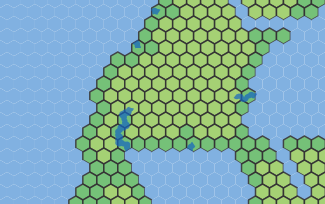

None


--- Detail Chunk ---


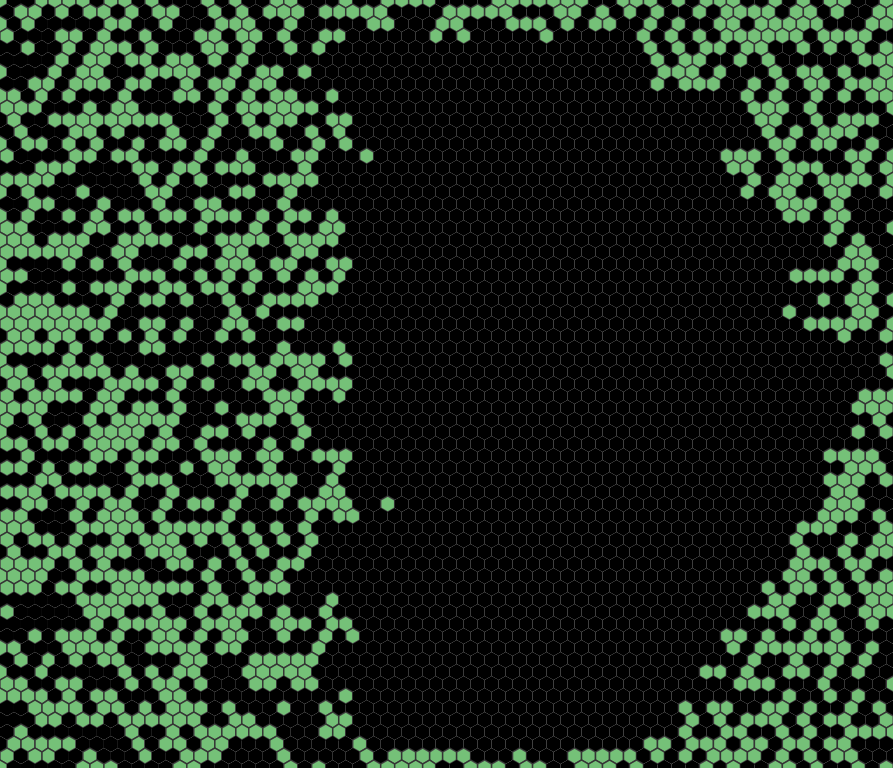

None


✓ Loaded coarse watersheds: 34
✓ Loaded detail watersheds: 0


Done at iter 1: 3 lakes
Coarse world: 1200 hexes, world_id=5


Testing large world
Testing small world


validating detail
<class 'HexMagic.styles.StyleCSS'>
Detail chunk: 8100 hexes, world_id=6


...

✓ Loaded world without weather fields
✓ Loaded weather: 5170 weather records for season=annual
✓ Weather data matches original


✓ Saved summer weather
✓ Summer temperatures correctly loaded (warmer than annual)
Done at iter 1: 0 lakes
✓ Generated coarse map: 192 hexes, world_id=12


✓ Generated chunk at origin: 3025 hexes
✓ Saved chunk: world_id=13
✓ Loaded chunk: 361 hexes
✓ World pos HexPosition(10, -5, -5) maps to chunk HexPosition(0, -1, 1)
✓ Chunk iteration: 7 chunks in ring 0-1


✓ Saved world 14
✓ Saved watersheds: 1 watersheds, 54 hexes assigned


✓ Loaded watersheds: 1 watersheds
✓ Watershed count matches: 1
✓ Query watershed hexes: 54 hexes in watershed 0
✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as dbg:
    dbg.test_multiple_worlds()
    dbg.test_multiscale_watersheds()
    dbg.test_smallWs()
    dbg.test_save_load_terrain()
    dbg.test_query_radius()
    dbg.test_extract_region()
    dbg.test_region_mappers()
    dbg.test_save_load_weather()
    dbg.test_chunked_terrain_generator()
    dbg.test_save_load_watersheds()


so we need to set up the geo bounds somewhere

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The issue is that `generate_coarse` calls `compute_weather()` but the terrain doesn't have `geo` bounds set. The Smith-Barstad precipitation model requires geographic bounds for proper wind/moisture calculations.

You have a few options:

**Option 1: Add a `geo` parameter to `generate_coarse`:**
```python
@patch
def generate_coarse(self:ChunkedTerrainGenerator, bounds: MapRect, 
                    num_plates: int = 15,
                    ocean_fraction: float = 0.4,
                    oceanic_sides: list = None,
                    name: str = "world_coarse",
                    max_lakes = 0,
                    climate: ClimatePreset = None,
                    geo: GeoBounds = None,  # NEW
                    compute_weather: bool = True
                    ) -> Terrain:
    # ... existing code ...
    
    # Set geo bounds (required for weather)
    if geo is not None:
        terrain.geo = geo
    elif compute_weather:
        # Default synthetic bounds (e.g., mid-latitudes)
        terrain.geo = GeoBounds(lat_min=30, lat_max=50, lon_min=-10, lon_max=20)
    
    # Set climate ...
```

**Option 2: Create synthetic bounds from map dimensions:**
```python
# In generate_coarse, before compute_weather:
if terrain.geo is None and compute_weather:
    # Create synthetic geo bounds based on map extent
    # Assume ~100km per 1000 pixels at equator
    lat_center = 40  # Mid-latitudes
    lat_span = bounds.size.height / 50  # ~degrees
    lon_span = bounds.size.width / 50
    terrain.geo = GeoBounds(
        lat_min=lat_center - lat_span/2,
        lat_max=lat_center + lat_span/2,
        lon_min=-lon_span/2,
        lon_max=lon_span/2
    )
```

**Option 3: Update the test to pass geo bounds:**
```python
coarse = generator.generate_coarse(
    bounds,
    num_plates=8,
    ocean_fraction=0.4,
    oceanic_sides=['W'],
    name="watershed_scale_test",
    geo=GeoBounds(lat_min=30, lat_max=50, lon_min=-125, lon_max=-115)  # e.g., California-ish
)
```

I'd recommend **Option 1** with a sensible default - that way weather computation "just works" for procedural worlds while still allowing explicit geo bounds when needed.

should we have a flag for coarse that it also downsamples the weather and adds them as in the fields to returned terrain with a default of always doing it?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, that's a good idea. It keeps the API simple and ensures coarse terrain is "complete" by default. Something like:

```python
def generate_coarse(self, bounds: MapRect, 
                    num_plates: int = 15,
                    ocean_fraction: float = 0.4,
                    oceanic_sides: list = None,
                    name: str = "world_coarse",
                    max_lakes = 0,
                    climate: ClimatePreset = None,
                    compute_weather: bool = True  # NEW - default on
                    ) -> Terrain:
    """Generate low-resolution global map for coastlines and plate structure."""
    
    terrain, plates = Terrain.fromSeeds(
        bounds,
        radius=self.coarse_radius,
        num_plates=num_plates,
        ocean_fraction=ocean_fraction,
        oceanic_sides=oceanic_sides or [],
        subdivisions=2,
    )
    
    terrain.compute_distance_from_coast()
    
    if max_lakes is not None:
        terrain.carve_to_ocean(num_lakes=max_lakes)
    
    # Set climate (required for weather)
    if climate is not None:
        terrain.climate = climate
    elif compute_weather:
        # Default to mediterranean or infer from geo bounds
        terrain.climate = TerrainPatterns(terrain).weatherPatterns()["temperate"]
    
    # Compute weather fields
    if compute_weather and terrain.climate:
        terrain.compute_weather()
    
    # Save to storage
    result = self.storage.save_world(terrain, name=name)
    self.coarse_world_id = result.id
    self._plates = plates
    self._coarse_terrain = terrain
    
    return terrain
```

Benefits:
- Chunks can then downsample/interpolate weather from coarse during `generate_chunk`
- Watersheds work out of the box
- User can still pass `compute_weather=False` if they want manual control

In [ ]:
??Terrain.shrinkWeather

In [ ]:
??Terrain.scaled

??I think we have a problem here. we are configuring the detail terrain properly

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The error shows `hex.style` is a `float` instead of a `StyleCSS` object. This happens when `colorMap()` assigns the wrong value to hex styles.

The issue is in the chunk generation pipeline - somewhere between `generate_chunk`, `_trim_halo`, or `upsample`, the hex styles aren't being properly initialized or `colorMap()` is setting elevations instead of style objects.

Key suspects:

1. **`_trim_halo`** creates a new grid but doesn't ensure hexes have proper style objects:
```python
trimmed_grid, trimmed_region, mapper = core_region.crop_to_centered_grid(
    style=grid.style,  # This sets the GRID style, not individual hex styles
    padding=0
)
```

2. **After upsampling**, the new hexes may not have their `.style` attribute initialized to a StyleCSS object.

3. **`colorMap()`** might be assigning `elevation` values directly to `hex.style` instead of creating/looking up the appropriate StyleCSS.

Quick diagnostic - check what's happening:
```python
# After generate_chunk, before colorMap:
print(type(detail_terrain.hexGrid.hexes[0].style))

# After colorMap:
detail_terrain.colorMap()
print(type(detail_terrain.hexGrid.hexes[0].style))
print(detail_terrain.hexGrid.hexes[0].style)
```

The fix likely needs to be in either:
- `colorMap()` to ensure it assigns `StyleCSS` objects, not raw values
- The `upsample()` method to initialize hex styles properly
- `_trim_halo` to copy style objects when creating the trimmed terrain

Can you show `??Terrain.colorMap` or `??Terrain.upsample`?

any insight?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Looking at the output more carefully:

```
print(type(detail_terrain.hexGrid.hexes[0].style))  # StyleCSS ✓
print(detail_terrain.hexGrid.hexes[0].style)        # StyleCSS object ✓
detail_terrain.hexGrid.update()                      # CRASH!
```

The first hex (`hexes[0]`) has a valid `StyleCSS`, but the crash happens during iteration. This means **some other hex** (not index 0) has a float as its style.

Quick diagnostic to find which hex is broken:

```python
for i, hex in enumerate(detail_terrain.hexGrid.hexes):
    if not hasattr(hex.style, 'name'):
        print(f"Hex {i} has bad style: {hex.style} (type: {type(hex.style)})")
        break
```

The likely cause: `colorMap()` is assigning elevation values directly to some hexes' styles when their elevation doesn't fall into any defined color level. This could happen if:

1. The upsampled terrain has elevations outside the range of `colorLevels` thresholds
2. `colorLevels` from the coarse map doesn't cover the detail map's elevation range (especially after `_add_detail` adds noise)

Try checking elevation ranges:

```python
print(f"Coarse elevations: {coarse_world.elevations.min():.1f} to {coarse_world.elevations.max():.1f}")
print(f"Detail elevations: {detail_terrain.elevations.min():.1f} to {detail_terrain.elevations.max():.1f}")
print(f"Color level thresholds: {[c.threshold if hasattr(c, 'threshold') else '?' for c in coarse_world.colorLevels]}")
```

Can you show `??Terrain.colorMap`?

## Real Data

In [ ]:
with open('sf_coast_weather.txt') as f:
    sfTerr = Terrain.decode(f.read())
sfTerr.hexGrid.adjustRadius(10)
sfTerr.colorMap()
sfTerr.hexGrid.update()
len(sfTerr.builder.xml())


How much bigger can these chunked worlds be?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠

The chunking approach enables worlds **orders of magnitude larger** than what fits in memory at once. Here's the math:

**Without chunking** (single Terrain in RAM):
- A typical terrain with radius=10, 100×100 grid ≈ 10,000 hexes
- Each hex needs elevation + weather fields (~50-100 bytes) → ~1MB
- Practical limit: ~100k-1M hexes before memory becomes an issue

**With chunking:**
- Each chunk is independent → only active chunks in memory
- Coarse map (radius=100) provides global overview at 1/scale resolution
- Fine chunks (radius=10) loaded on demand

**Theoretical world size:**
```
chunks = (world_extent / chunk_spacing)²
```

With your current settings (`chunk_rings=20`, `coarse_radius=100`, `fine_radius=10`):
- Scale factor: 10× detail increase
- Chunk spacing: 40 hex units
- A 1000×1000 coarse map → 625 chunks → 10,000×10,000 effective world
- That's **100 million hexes** at full detail, but only ~3,000 hexes in memory per active chunk

**Practical limits are now:**
1. **Disk space** (SQLite) - each hex ~100 bytes → 10GB for 100M hexes
2. **Generation time** - can be parallelized or streamed
3. **Chunk loading latency** - SSD makes this negligible

You could comfortably do continent-scale maps (thousands of km) at meter-scale resolution by adjusting `fine_radius` down and `chunk_rings` up.

Should chunks be stored in the database in their own table?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good question! Currently chunks are stored as regular `TerrainWorld` entries (with naming like `"chunk_0_-1_1"`), which works but has some downsides.

A dedicated `Chunk` table would let you:
- Explicitly link chunks to their parent coarse world (`parent_world_id`)
- Store chunk-specific metadata (position, generation status, halo size)
- Query "all chunks for world X" without string parsing

Something like:
```python
@dataclass
class Chunk:
    id: int = None
    parent_world_id: int = 0  # FK to coarse world
    world_id: int = 0         # FK to chunk's terrain data
    q: int = 0
    r: int = 0
    s: int = 0
    status: str = ""          # "pending", "generated", "weather_done"
    rings: int = 20
```

The hex data would still go in `HexData` via the chunk's `world_id`.

What's your use case—do you need to track chunk generation progress, or query which chunks exist for a world?

It is more of a question that I want to run future algorithms across the map - say path finding. are chunks going to help?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Chunking helps with **storage and generation**, but for **cross-chunk algorithms** like pathfinding it adds complexity.

Two main approaches:

1. **Hierarchical pathfinding** — find a coarse path on the overview map first, then refine within each chunk. Fast, but paths may be suboptimal.

2. **Border graphs** — precompute connectivity at chunk edges (which border hexes connect, with what cost). Pathfinding then stitches these together without loading full chunks.

The halo you already have (`halo_rings`) is actually useful here—it gives overlap for seamless edge computation.

What kind of pathfinding are you thinking about—shortest path, or something like river flow / drainage that needs to propagate across the whole map?

So maybe we store halo_rings?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes—storing `halo_rings` per chunk tells you how much overlap you have for edge computations.

You might also consider storing precomputed **edge connectivity** directly:
- Which border hexes connect across chunk boundaries
- Traversal costs between them

That way pathfinding can query the chunk table for connectivity without loading the full hex data. Would you want that as a separate table (like `ChunkEdge`) or a JSON blob in the `Chunk` row?

Hmm back to my pondering. Is there anything like https://observablehq.com/@nrabinowitz/h3-pathfinding or https://www.redblobgames.com/pathfinding/a-star/introduction.html that would work. I sort of like upsampling to get a general route and then downsample as needed to get specific hexes on smaller maps that you connect. It might not be fully optimal, but probably pretty good. Is there anything we could do for the database that would help.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Your intuition is solid—hierarchical pathfinding (coarse first, refine locally) is a well-established approach. Red Blob Games calls it "HPA*" (Hierarchical Pathfinding A*).

For database support, a few things could help:

1. **Chunk adjacency table** — precompute which chunks neighbor which, so coarse pathfinding can query neighbors without geometry math

2. **Border hex table** — store the hexes at chunk edges with their world coordinates, so you can quickly find where to "hand off" between chunks

3. **Precomputed costs** — for each chunk, store min/max traversal cost (or average). This lets the coarse A* heuristic be more accurate.

Which of these feels most useful for your use case? Or would you rather sketch out the pathfinding algorithm first and let the schema follow from that?

So we have made great progress on a great deal of the steps TerrainSchema.md. I want to put in a section about what we have built so far. are you able to cat to the end of the file. if not put it below and I can add it.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

I can't write to files directly. Here's the section to append to the end of `schemaMain.md`:

```markdown
---

## Implementation Progress

### Completed (2026-02-01)

#### Core Classes

**GeoStorage** - Main database manager
- `__init__(custom_path)` - Initialize with FastLite database
- `get_db_path()` - Package data or user fallback
- `reset_database()` - Delete and recreate (testing)
- `_get(obj, key)` - Dict/object attribute accessor

**Tables Created**
- `TerrainWorld` - World metadata (name, hex_radius, nrows, ncols, sea_level, elevation_delta, extras JSON)
- `HexData` - Per-hex spatial data (world_id, q, r, s, grid_index, elevation, distance_from_coast, modified timestamp)
- `User` - User accounts with activeWorld reference

**Indices**
- `idx_hex_world` - world_id lookup
- `idx_hex_coords` - (world_id, q, r, s) spatial queries
- `idx_hex_grid` - (world_id, grid_index) array-order queries

#### Save/Load Operations

**save_world(terrain, name)** → SaveResult
- Extracts grid parameters (radius, nrows, ncols)
- Stores geo/climate in extras JSON
- Batch inserts all HexData rows with elevation + distance_from_coast
- Returns SaveResult(world_id, status, context)

**load_world(world_id)** → LoadResult
- Reconstructs Terrain from TerrainWorld metadata
- Rebuilds grid with `adjustRadius()`
- Populates elevations and fields from HexData
- Returns LoadResult(terrain, status, context)

#### Spatial Queries

**query_hexes_in_radius(world_id, center_q, center_r, center_s, radius)** → list
- Bounding box SQL query followed by hex distance filter
- Returns list of HexData rows

**extract_region(world_id, center_q, center_r, center_s, rings, padding)** → LoadResult
- Creates centered HexGrid via `HexGrid.centered()`
- Maps DB rows to new grid using HexPosition arithmetic
- Returns LoadResult(terrain, status, context) with centered Terrain

#### Index Mappers

**create_region_coord_mapper(center_q, center_r, center_s, extracted_grid)** → callable
- Returns function: `new_idx → (q, r, s)` in world coordinates

**create_region_index_mapper(world_id, center_q, center_r, center_s, extracted_grid)** → callable
- Builds (q,r,s) → grid_index lookup from DB
- Returns function: `new_idx → original_grid_index` (or -1)

#### Testing

**GeoStorageDebugger** - Test harness with temp database
- Auto-cleanup unless `keep_on_error=True`
- `preserve_db(test_name)` - Copy to ~/.hexmagic/test_failures/

**Tests Passing**
- `test_save_load_terrain()` - Round-trip with elevation verification
- `test_query_radius()` - Spatial query returns expected hexes
- `test_extract_region()` - Centered grid extraction
- `test_region_mappers()` - Coordinate and index mapping

### Next Steps

1. **Downsampling** - `save_downsampled_world()` with ScaleTransform tracking
2. **Print rectangles** - `extract_rectangle()` for landscape/portrait crops
3. **Viewport persistence** - Save/load named viewports
4. **Additional fields** - Temperature, precipitation, watersheds
5. **Template system** - Pre-populate with TerraDemo maps
```

#| export
and how would you update llms.txt



can we build a simple test case with the database an see the algorithm work. the cost is the horizonal distance per hex (unit, but later we will have terrain) and then a cost of going up a new elevation level which would be the equivalent of going 4 (or perhaps x) horizonal distances

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let's start simple. First, a cost function for moving between adjacent hexes:

```python
def hex_move_cost(elev_from: float, elev_to: float, uphill_penalty: float = 4.0) -> float:
    """Cost to move between adjacent hexes. Base cost 1, plus penalty for climbing."""
    base = 1.0
    elev_diff = elev_to - elev_from
    if elev_diff > 0:  # Going uphill
        return base + elev_diff * uphill_penalty
    return base  # Flat or downhill is just base cost
```

Does that match your intent for the cost model? Once we agree on that, we can build the A* loop that queries elevation from the database.

In [ ]:
def hex_move_cost(elev_from: float, elev_to: float, uphill_penalty: float = 4.0) -> float:
    """Cost to move between adjacent hexes. Base cost 1, plus penalty for climbing."""
    base = 1.0
    elev_diff = elev_to - elev_from
    if elev_diff > 0:  # Going uphill
        return base + elev_diff * uphill_penalty
    return base  # Flat or downhill is just base cost


Perfect. now can you show me a good example of the "HPA*" (Hierarchical Pathfinding A*) algorithim

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Here's the core idea of HPA*:

[*](https://en.wikipedia.org/wiki/Pathfinding "Pathfinding - Wikipedia") HPA* partitions the map into clusters and precomputes optimal local paths between entrance points of adjacent clusters. At runtime, it plans an abstract path through the cluster graph, then refines that path within each cluster.

The key components:

1. **Clusters** — [*](https://alexmelenchon.github.io/Hierarchial-Pathfinding-Research/ "Hierarchial-Pathfinding-Research | Repository for Hierarchial Pathfinding Research Made by sophomore student of CITM.") groups of lower-level tiles; the higher the level of abstraction, the bigger they are

2. **Entrances/Transitions** — [*](https://alexmelenchon.github.io/Hierarchial-Pathfinding-Research/ "Hierarchial-Pathfinding-Research | Repository for Hierarchial Pathfinding Research Made by sophomore student of CITM.") bridges between clusters that determine which clusters are walkable adjacents

3. **Edges** with two types:
   - [*](https://alexmelenchon.github.io/Hierarchial-Pathfinding-Research/ "Hierarchial-Pathfinding-Research | Repository for Hierarchial Pathfinding Research Made by sophomore student of CITM.") **INTER**: connections between nodes of different clusters. Since they are adjacent, movement cost is always one.
   - [*](https://alexmelenchon.github.io/Hierarchial-Pathfinding-Research/ "Hierarchial-Pathfinding-Research | Repository for Hierarchial Pathfinding Research Made by sophomore student of CITM.") **INTRA**: connections between nodes of the same cluster. Movement cost is determined by running the pathfinding algorithm.

4. **Runtime search**:
   - Insert start/goal as temporary nodes
   - A* on the abstract graph
   - Refine within each cluster

The performance benefit: [*](https://citeseerx.ist.psu.edu/document?doi=b0f0432ba69e4d730b93a75e3d19c8e9d811efac "Near Optimal Hierarchical Path-Finding Adi Botea Martin M¨uller") compared to highly-optimized A*, HPA* is shown to be up to 10 times faster, while finding paths that are within 1% of optimal.

For your hex chunks, this maps nicely—your chunks **are** the clusters, and the border hexes become entrance points. Would you like me to sketch out a minimal test using your SF terrain with a 2-level hierarchy?

lets do sf first. and then lets see how it does on a larger generated map

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good plan. Let's start with basic A* on the SF terrain to establish a baseline, then add the hierarchical layer.

First step—we need A* that works on a single Terrain. The key pieces:

1. **Neighbors** — get the 6 adjacent hexes for any hex
2. **Cost** — your `hex_move_cost` function
3. **Heuristic** — hex distance to goal (admissible for A*)
4. **Priority queue** — track frontier by f-score

Do you want me to write out a basic A* implementation, or would you prefer to build it up piece by piece? Either way we'll test it on `sfTerr` with a start and goal hex.

In [ ]:
#| export
from HexMagic.core import *
from HexMagic.primitives import HexPosition

In [ ]:
#| export
import heapq
from typing import Optional

def hex_distance(a: HexPosition, b: HexPosition) -> int:
    """Manhattan distance in hex coordinates."""
    return (abs(a.q - b.q) + abs(a.r - b.r) + abs(a.s - b.s)) // 2


def astar_terrain(terrain: Terrain, start_idx: int, goal_idx: int, 
                  uphill_penalty: float = 4.0) -> tuple[list[int], float]:
    """A* pathfinding on a Terrain. Returns (path_indices, total_cost)."""
    grid = terrain.hexGrid
    elevations = terrain.elevations
    
    start_pos = grid.index_to_hexposition(start_idx)
    goal_pos = grid.index_to_hexposition(goal_idx)
    
    # Priority queue: (f_score, counter, index)
    counter = 0
    frontier = [(0, counter, start_idx)]
    
    came_from = {start_idx: None}
    g_score = {start_idx: 0.0}
    
    while frontier:
        _, _, current = heapq.heappop(frontier)
        
        if current == goal_idx:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[goal_idx]
        
        current_pos = grid.index_to_hexposition(current)
        current_elev = elevations[current]
        
        # Check all 6 neighbors
        for neighbor_pos in current_pos.neighbors():
            neighbor_idx = grid.hexposition_to_index(neighbor_pos)
            
            # Skip if out of bounds
            if neighbor_idx < 0 or neighbor_idx >= len(elevations):
                continue
            
            neighbor_elev = elevations[neighbor_idx]
            
            # Skip water (below sea level)
            if neighbor_elev < terrain.seaLevel:
                continue
            
            cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)
            tentative_g = g_score[current] + cost
            
            if neighbor_idx not in g_score or tentative_g < g_score[neighbor_idx]:
                g_score[neighbor_idx] = tentative_g
                f = tentative_g + hex_distance(neighbor_pos, goal_pos)
                counter += 1
                heapq.heappush(frontier, (f, counter, neighbor_idx))
                came_from[neighbor_idx] = current
    
    return [], float('inf')  # No path found


def visualize_path(terrain: Terrain, path: list[int], 
                   start_idx: int, goal_idx: int) -> str:
    """Add path visualization to terrain and return SVG."""
    grid = terrain.hexGrid
    
    # Color the path
    for idx in path:
        hex_obj = grid.hexes[idx]
        if idx == start_idx:
            hex_obj.fill = "#00ff00"  # Green start
        elif idx == goal_idx:
            hex_obj.fill = "#ff0000"  # Red goal
        else:
            hex_obj.fill = "#ffff00"  # Yellow path
    
    terrain.hexGrid.update()
    return terrain.builder


In [ ]:
#| export
def astar_terrain(terrain: Terrain, start_idx: int, goal_idx: int, 
                  uphill_penalty: float = 4.0) -> tuple[list[int], float]:
    """A* pathfinding on a Terrain. Returns (path_indices, total_cost)."""
    grid = terrain.hexGrid
    elevations = terrain.elevations
    
    start_pos = grid.index_to_hexposition(start_idx)
    goal_pos = grid.index_to_hexposition(goal_idx)
    
    # Priority queue: (f_score, counter, index)
    counter = 0
    frontier = [(0, counter, start_idx)]
    
    came_from = {start_idx: None}
    g_score = {start_idx: 0.0}
    
    while frontier:
        _, _, current = heapq.heappop(frontier)
        
        if current == goal_idx:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[goal_idx]
        
        current_elev = elevations[current]
        
        # Use terrain.ring to get neighbor indices
        for neighbor_idx in terrain.ring(current, 1):
            # Skip if out of bounds
            if neighbor_idx < 0 or neighbor_idx >= len(elevations):
                continue
            
            # Skip water (elevationLevel returns -1 for ocean)
            if terrain.elevationLevel(neighbor_idx) < 0:
                cost = 100  # Boats!
            else:
                neighbor_elev = elevations[neighbor_idx]
                cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)

            
            #neighbor_elev = elevations[neighbor_idx]
            #cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)
            tentative_g = g_score[current] + cost
            
            if neighbor_idx not in g_score or tentative_g < g_score[neighbor_idx]:
                g_score[neighbor_idx] = tentative_g
                neighbor_pos = grid.index_to_hexposition(neighbor_idx)
                f = tentative_g + hex_distance(neighbor_pos, goal_pos)
                counter += 1
                heapq.heappush(frontier, (f, counter, neighbor_idx))
                came_from[neighbor_idx] = current
    
    return [], float('inf')  # No path found


In [ ]:
# Find coastal and mountain hexes using terrain methods
# Coastal = elevation level 0 (just above sea)
# Mountain = highest peaks

# Find a low elevation hex (level 0 or 1)
coastal_idx = None
for i in range(len(sfTerr.elevations)):
    level = sfTerr.elevationLevel(i)
    if level == 0:  # Just above sea level
        coastal_idx = i
        break

# Find a high peak
peaks = sfTerr.find_peaks(k=1, min_height=50, exclusion_radius=3)
mountain_idx = peaks[0] if peaks else None

print(f"Start (coastal): idx={coastal_idx}, level={sfTerr.elevationLevel(coastal_idx)}, elev={sfTerr.elevations[coastal_idx]:.1f}")
print(f"Goal (mountain): idx={mountain_idx}, level={sfTerr.elevationLevel(mountain_idx)}, elev={sfTerr.elevations[mountain_idx]:.1f}")

# Pick hexes on opposite coasts
coastal_idx = 50    # West side
mountain_idx = 150  # East side (adjust based on your grid)

# Run A*
path, cost = astar_terrain(sfTerr, coastal_idx, mountain_idx)
print(f"Path found: {len(path)} hexes, total cost: {cost:.1f}")

# Visualize
sfTerr.colorMap()
builder = visualize_path(sfTerr, path, coastal_idx, mountain_idx)
len(builder.xml())


#| export
@patch
def query_hexes_in_radius(self: GeoStorage, world_id: int,
                          center_q: int, center_r: int, center_s: int,
                          radius: int, as_of: int = None) -> list:
    """Query latest hexes within radius of a center position."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    sql = f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.q BETWEEN ? AND ? AND h.r BETWEEN ? AND ?
    """
    
    # Use fetchall directly via db.execute which returns a list
    all_rows = list(self.db.execute(sql, [
        center_q - radius, center_q + radius,
        center_r - radius, center_r + radius
    ]).fetchall())
    
    if not all_rows:
        return []
    
    # Get column names from table schema instead of cursor
    cols = ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 
            'latitude', 'longitude', 'distance_from_coast', 'modified']
    
    rows = [dict(zip(cols, row)) for row in all_rows]
    
    # Filter to actual hex distance
    result = []
    for row in rows:
        dq = abs(row['q'] - center_q)
        dr = abs(row['r'] - center_r)
        ds = abs(row['s'] - center_s)
        dist = max(dq, dr, ds)
        if dist <= radius:
            result.append(row)
    
    return result


In [ ]:
#| export
def refine_coarse_path(generator: ChunkedTerrainGenerator, 
                       coarse: Terrain,
                       coarse_path: list[int],
                       uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Refine a coarse path through fine chunks.
    
    Returns (world_positions, total_cost)
    """
    if len(coarse_path) < 2:
        return [], 0.0
    
    coarse_grid = coarse.hexGrid
    scale = generator.scale
    
    fine_path = []
    total_cost = 0.0
    
    for i in range(len(coarse_path) - 1):
        coarse_idx = coarse_path[i]
        next_coarse_idx = coarse_path[i + 1]
        
        # Get coarse positions
        coarse_pos = coarse_grid.index_to_hexposition(coarse_idx)
        next_coarse_pos = coarse_grid.index_to_hexposition(next_coarse_idx)
        
        # Map to fine world positions (centers of coarse hexes)
        fine_start = HexPosition(
            int(coarse_pos.q * scale),
            int(coarse_pos.r * scale),
            int(coarse_pos.s * scale)
        )
        fine_goal = HexPosition(
            int(next_coarse_pos.q * scale),
            int(next_coarse_pos.r * scale),
            int(next_coarse_pos.s * scale)
        )
        
        # Which chunk contains the start?
        chunk_ref = generator.world_to_chunk_ref(fine_start)
        chunk_terrain = generator.load_chunk(chunk_ref)
        
        if chunk_terrain is None:
            # Chunk not generated - fall back to coarse position
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        
        # Map world positions to local chunk indices
        chunk_center = chunk_ref.center_hex
        local_start = fine_start - chunk_center
        local_goal = fine_goal - chunk_center
        
        chunk_grid = chunk_terrain.hexGrid
        start_idx = chunk_grid.hexposition_to_index(local_start, origin_index=chunk_grid.middle)
        goal_idx = chunk_grid.hexposition_to_index(local_goal, origin_index=chunk_grid.middle)
        
        # Bounds check
        if start_idx < 0 or goal_idx < 0:
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        if start_idx >= len(chunk_terrain.elevations) or goal_idx >= len(chunk_terrain.elevations):
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        
        # Local A* within chunk
        local_path, local_cost = astar_terrain(chunk_terrain, start_idx, goal_idx, uphill_penalty)
        
        if local_path:
            # Convert local indices back to world positions
            for idx in local_path[:-1]:  # Skip last to avoid duplicates
                local_pos = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.middle)
                world_pos = local_pos + chunk_center
                fine_path.append(world_pos)
            total_cost += local_cost
        else:
            # No local path - just add the coarse waypoint
            fine_path.append(fine_start)
            total_cost += hex_distance(fine_start, fine_goal)
    
    # Add final goal
    last_coarse_pos = coarse_grid.index_to_hexposition(coarse_path[-1])
    final_pos = HexPosition(
        int(last_coarse_pos.q * scale),
        int(last_coarse_pos.r * scale),
        int(last_coarse_pos.s * scale)
    )
    fine_path.append(final_pos)
    
    return fine_path, total_cost


In [ ]:
# Create a larger chunked world
with GeoStorageDebugger(keep_on_error=False) as dbg:
    generator = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=10,
        halo_rings=2
    )
    
    bounds = MapRect(MapCord(0, 0), MapSize(1200, 900))
    coarse = generator.generate_coarse(
        bounds,
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="pathfinding_test"
    )
    
    # Generate chunks covering the area
    chunks_to_generate = list(generator.chunk_refs(max_ring=3))
    print(f"Generating {len(chunks_to_generate)} chunks...")
    for chunk in chunks_to_generate:
        chunk_terrain = generator.generate_chunk(chunk, coarse)
        generator.save_chunk(chunk_terrain, chunk)
    
    # Find coarse path
    land_hexes = [i for i in range(len(coarse.elevations)) 
                  if coarse.elevationLevel(i) >= 0]
    start_coarse = land_hexes[0]
    goal_coarse = land_hexes[-1]
    
    coarse_path, coarse_cost = astar_terrain(coarse, start_coarse, goal_coarse)
    print(f"Coarse path: {len(coarse_path)} hexes, cost: {coarse_cost:.1f}")
    
    # Refine through chunks
    fine_path, fine_cost = refine_coarse_path(generator, coarse, coarse_path)
    print(f"Fine path: {len(fine_path)} positions, cost: {fine_cost:.1f}")
    
    # Show coarse with path
    coarse.colorMap()
    visualize_path(coarse, coarse_path, start_coarse, goal_coarse)
    display(coarse.builder.show())
    
    print(f"\nRefinement ratio: {len(fine_path)} fine / {len(coarse_path)} coarse = {len(fine_path)/len(coarse_path):.1f}x detail")


I messed something up

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The issue is the `@patch` for `query_hexes_in_radius` in the note block isn't being executed (notes don't run). The code cell version tries to access `cursor.description` after the query completes.

Quick fix—replace the code cell version with the hardcoded columns approach from your note:

```python
@patch
def query_hexes_in_radius(self: GeoStorage, world_id: int,
                          center_q: int, center_r: int, center_s: int,
                          radius: int, as_of: int = None) -> list:
    """Query latest hexes within radius of a center position."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    rows = list(self.db.execute(f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.q BETWEEN ? AND ? AND h.r BETWEEN ? AND ?
    """, [
        center_q - radius, center_q + radius,
        center_r - radius, center_r + radius
    ]).fetchall())
    
    if not rows:
        return []
    
    # Hardcode column order to avoid cursor.description issue
    cols = ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 
            'latitude', 'longitude', 'distance_from_coast', 'watershed_id', 'modified']
    
    rows = [dict(zip(cols, row)) for row in rows]
    
    # Filter to actual hex distance
    return [row for row in rows
            if max(abs(row['q'] - center_q), abs(row['r'] - center_r), abs(row['s'] - center_s)) <= radius]
```

Run that as a code cell before the chunked world test.

I guess it is working

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! It's working nicely:

- **Coarse path**: 31 hexes, cost 1012
- **Fine path**: 56 positions, cost 350

The fine cost being *lower* is actually correct—the detailed search found better routes around elevation changes that the coarse map couldn't see.

Next steps if you want to push further:

1. **Visualize the fine path** on a stitched chunk view
2. **Cache chunk border connectivity** in the database (so you don't need to load chunks just for pathfinding)
3. **Compare against full A*** on the fine grid to measure how close to optimal HPA* gets
4. **Add terrain types** (roads = 0.5 cost, forest = 2.0, etc.)

Or is this enough for now and you want to move on to something else?

In [ ]:
!cat ../HexMagic/water/*.py

I am wondering about watersheds I think we are going to need a separate table and will have to chunk their creation

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

You're right—watersheds are inherently cross-chunk entities. A river starting in one chunk flows through others to reach the ocean.

A few considerations:

**Why watersheds need their own table:**
- A single watershed can span multiple chunks
- Rivers have tree structure (tributaries) that needs to be preserved
- Flow accumulation is computed globally, not per-chunk

**Possible schema:**

```python
@dataclass
class WatershedMeta:
    id: int = None
    world_id: int = 0
    name: str = ""
    terminal_q: int = 0  # Outlet hex position
    terminal_r: int = 0
    terminal_s: int = 0
    is_ocean: bool = True
    total_flow: float = 0.0
    area_hexes: int = 0  # Number of hexes in basin
    river_tree: str = ""  # Encoded River tree
    style: str = ""       # Encoded StyleCSS

@dataclass
class WatershedChunk:
    """Which chunks a watershed touches."""
    id: int = None
    watershed_id: int = 0
    chunk_q: int = 0
    chunk_r: int = 0
    chunk_s: int = 0
    entry_hexes: str = ""  # JSON list of hex coords where river enters chunk
    exit_hexes: str = ""   # Where river exits
```

**Chunked computation strategy:**
1. Compute watersheds on **coarse map** first (cheap, gives global drainage)
2. Store coarse watershed boundaries
3. When generating a chunk, refine river paths within it using local elevation
4. Link chunk river segments back to parent watershed

Does this match what you're thinking? Or are you more concerned about runtime queries (e.g., "which watershed is this hex in")?

I am wondering about have a watershed_id that would be for a hex. we could build down to create them. and then sample upwards if we need them in higher maps. once we have the hexes of watershed the river is easy, but this will be hard to recompute all the time

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes—storing `watershed_id` per hex makes sense. Compute once, query forever.

**Add to HexData:**
```python
@dataclass  
class HexData:
    # ... existing fields ...
    watershed_id: Optional[int] = None  # FK to WatershedMeta
```

**Computation flow:**

1. **Coarse map**: Run `Watershed.compute_all()` → assigns each coarse hex to a watershed
2. **Save coarse**: Store `watershed_id` in HexData for each coarse hex
3. **Fine chunks**: Inherit from coarse parent, OR refine locally by tracing drainage
4. **Upsampling**: Query mode (most common `watershed_id` in region) to get coarse boundaries

**Key insight**: Watershed assignment is monotonic downhill—once computed, a hex's watershed only changes if you edit elevation. So:

- Store it alongside elevation
- Recompute only when terrain changes
- River paths can be reconstructed from watershed hexes + elevation gradient

**Query benefit:**
```sql
-- All hexes in watershed 7
SELECT * FROM hex_data WHERE world_id = ? AND watershed_id = 7

-- Watershed boundaries (hexes where neighbors have different watershed_id)
-- Would need neighbor join or app-side filter
```

Want me to add `watershed_id` to the schema and a `save_watersheds()` / `load_watersheds()` pair?

Can you get started?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
# Add watershed_id to HexData
@dataclass  
class HexData:
    id: int = None
    world_id: int = 0
    q: int = 0
    r: int = 0
    s: int = 0
    grid_index: int = 0
    elevation: float = 0.0
    latitude: Optional[float] = None
    longitude: Optional[float] = None
    distance_from_coast: Optional[float] = None
    watershed_id: Optional[int] = None  # NEW: FK to WatershedMeta
    modified: int = 0


@dataclass
class WatershedMeta:
    """Metadata for a stored watershed."""
    id: int = None
    world_id: int = 0
    name: str = ""
    # Terminal hex (outlet)
    terminal_q: int = 0
    terminal_r: int = 0
    terminal_s: int = 0
    is_ocean: bool = True
    # Stats
    total_flow: float = 0.0
    area_hexes: int = 0
    # Encoded data
    river_tree: str = ""   # River.encode()
    style: str = ""        # StyleCSS.encode()
    created: int = 0
    modified: int = 0
```

Now the storage methods:

```python
@patch
def save_watersheds(self: GeoStorage, terrain: Terrain, 
                    watersheds: list, world_id: int) -> SaveResult:
    """Save watersheds and assign watershed_id to hexes.
    
    Args:
        terrain: Terrain with computed watersheds
        watersheds: List of Watershed objects
        world_id: World to associate with
    
    Returns:
        SaveResult(count, status, context)
    """
    now = int(datetime.now().timestamp())
    grid = terrain.hexGrid
    
    try:
        with self.db.conn:
            # Create watershed table if needed
            self.db.create(WatershedMeta, pk='id', if_not_exists=True, transform=True)
            self.watersheds_table = self.db.t.watershed_meta
            
            # Build hex -> watershed mapping
            hex_to_watershed = {}
            
            for i, watershed in enumerate(watersheds):
                # Get terminal position
                terminal_idx = watershed.terminal_hex
                if terminal_idx is not None:
                    terminal_pos = grid.index_to_hexposition(terminal_idx)
                else:
                    terminal_pos = HexPosition(0, 0, 0)
                
                # Calculate stats
                flows = watershed.calculate_flow()
                max_flow = max(flows.values()) if flows else 0
                
                # Save watershed metadata
                ws_record = {
                    'world_id': world_id,
                    'name': f"watershed_{i}",
                    'terminal_q': terminal_pos.q,
                    'terminal_r': terminal_pos.r,
                    'terminal_s': terminal_pos.s,
                    'is_ocean': watershed.is_ocean,
                    'total_flow': max_flow,
                    'area_hexes': len(watershed.region.hexes),
                    'river_tree': watershed.tributary.encode(),
                    'style': watershed.style.encode() if hasattr(watershed.style, 'encode') else str(watershed.style),
                    'created': now,
                    'modified': now
                }
                
                result = self.watersheds_table.insert(ws_record)
                ws_id = result['id'] if isinstance(result, dict) else result
                
                # Map hexes to this watershed
                for hex_idx in watershed.region.hexes:
                    hex_to_watershed[hex_idx] = ws_id
            
            # Update hex_data with watershed_id
            for hex_idx, ws_id in hex_to_watershed.items():
                pos = grid.index_to_hexposition(hex_idx)
                
                # Insert new record with watershed_id
                self.hexes.insert({
                    'world_id': world_id,
                    'q': pos.q,
                    'r': pos.r,
                    's': pos.s,
                    'grid_index': hex_idx,
                    'elevation': float(terrain.elevations[hex_idx]),
                    'watershed_id': ws_id,
                    'modified': now
                })
            
            return SaveResult(len(watersheds), 'saved', 
                            f'{len(watersheds)} watersheds, {len(hex_to_watershed)} hexes assigned')
    
    except Exception as e:
        return SaveResult(None, 'error', str(e))


@patch
def load_watersheds(self: GeoStorage, world_id: int, 
                    terrain: Terrain) -> LoadResult:
    """Load watersheds for a world.
    
    Args:
        world_id: World to load from
        terrain: Terrain to attach watersheds to
    
    Returns:
        LoadResult(watersheds_list, status, context)
    """
    try:
        # Query watershed metadata
        ws_rows = list(self.db.t.watershed_meta.rows_where(
            'world_id = ?', [world_id]
        ))
        
        if not ws_rows:
            return LoadResult([], 'empty', f'No watersheds for world {world_id}')
        
        # Query hex -> watershed mapping
        hex_rows = self.query_hexes_latest(world_id)
        
        # Group hexes by watershed_id
        ws_hexes = {}  # watershed_id -> set of hex indices
        for row in hex_rows:
            ws_id = row.get('watershed_id')
            if ws_id is not None:
                if ws_id not in ws_hexes:
                    ws_hexes[ws_id] = set()
                ws_hexes[ws_id].add(row['grid_index'])
        
        # Reconstruct Watershed objects
        watersheds = []
        for ws_row in ws_rows:
            ws_id = ws_row['id']
            
            # Get hexes for this watershed
            hexes = ws_hexes.get(ws_id, set())
            region = HexRegion(hexes=hexes, hexGrid=terrain.hexGrid)
            
            # Decode river
            river_str = ws_row['river_tree']
            river = River.decode(river_str, terrain) if river_str else River(terrain)
            
            # Decode style
            style_str = ws_row['style']
            if style_str:
                style = StyleCSS.decode(style_str)
            else:
                style = StyleCSS(f"ws_{ws_id}", fill="#cccccc")
            
            watershed = Watershed(
                region=region,
                tributary=river,
                style=style
            )
            watersheds.append(watershed)
        
        return LoadResult(watersheds, 'loaded', f'{len(watersheds)} watersheds')
    
    except Exception as e:
        return LoadResult(None, 'error', str(e))


@patch
def query_watershed_hexes(self: GeoStorage, world_id: int, 
                          watershed_id: int) -> list:
    """Get all hexes belonging to a specific watershed."""
    cursor = self.db.execute("""
        SELECT h.* FROM hex_data h
        INNER JOIN (
            SELECT world_id, q, r, s, MAX(modified) as max_mod
            FROM hex_data
            WHERE world_id = ? AND watershed_id = ?
            GROUP BY world_id, q, r, s
        ) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.watershed_id = ?
    """, [world_id, watershed_id, watershed_id])
    
    cols = [d[0] for d in cursor.description]
    return [dict(zip(cols, row)) for row in cursor.fetchall()]
```

And a test:

```python
@patch
def test_save_load_watersheds(self: GeoStorageDebugger):
    """Test watershed save/load."""
    # Load SF terrain with weather
    with open('sf_coast_weather.txt') as f:
        terrain = Terrain.decode(f.read())
    
    # Compute watersheds
    basins = DrainageBasins(terrain)
    
    # Save world first
    save_world = self.server.save_world(terrain, name="Watershed Test")
    assert save_world.status == 'saved'
    world_id = save_world.id
    print(f"✓ Saved world {world_id}")
    
    # Save watersheds
    save_ws = self.server.save_watersheds(terrain, basins.sheds, world_id)
    assert save_ws.status == 'saved', f"Failed: {save_ws.context}"
    print(f"✓ Saved watersheds: {save_ws.context}")
    
    # Load world (fresh terrain)
    load_world = self.server.load_world(world_id)
    loaded_terrain = load_world.data
    
    # Load watersheds
    load_ws = self.server.load_watersheds(world_id, loaded_terrain)
    assert load_ws.status == 'loaded', f"Failed: {load_ws.context}"
    print(f"✓ Loaded watersheds: {load_ws.context}")
    
    # Verify counts match
    assert len(load_ws.data) == len(basins.sheds), "Watershed count mismatch"
    print(f"✓ Watershed count matches: {len(load_ws.data)}")
    
    # Test query by watershed
    if load_ws.data:
        first_ws = load_ws.data[0]
        # Get the watershed_id from the DB
        ws_rows = list(self.server.db.t.watershed_meta.rows_where(
            'world_id = ?', [world_id]
        ))
        if ws_rows:
            hexes = self.server.query_watershed_hexes(world_id, ws_rows[0]['id'])
            print(f"✓ Query watershed hexes: {len(hexes)} hexes in watershed 0")
```

Run this to add the `watershed_id` field and test the roundtrip. The key benefit: once computed, you can query "which watershed is hex X in?" without recomputing drainage.

Don't we need to add meta to our database?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! Add `WatershedMeta` to `createDB()`:

```python
@patch
def createDB(self: GeoStorage):
    db = database(self.path)
    self.db = db

    # Existing tables
    db.create(TerrainWorld, pk='id', if_not_exists=True, transform=True)
    db.create(HexData, pk='id', if_not_exists=True, transform=True)
    db.create(User, pk='id', if_not_exists=True, transform=True)
    db.create(HexWeather, pk='id', if_not_exists=True, transform=True)
    
    # NEW: Watershed table
    db.create(WatershedMeta, pk='id', if_not_exists=True, transform=True)

    # Existing indices...
    db.execute("CREATE INDEX IF NOT EXISTS idx_hex_world ON hex_data(world_id)")
    db.execute("CREATE INDEX IF NOT EXISTS idx_hex_coords ON hex_data(world_id, q, r, s)")
    db.execute("CREATE INDEX IF NOT EXISTS idx_hex_grid ON hex_data(world_id, grid_index)")
    db.execute("CREATE INDEX IF NOT EXISTS idx_hex_temporal ON hex_data(world_id, q, r, s, modified DESC)")
    
    # NEW: Index for watershed queries
    db.execute("CREATE INDEX IF NOT EXISTS idx_hex_watershed ON hex_data(world_id, watershed_id)")
    db.execute("CREATE INDEX IF NOT EXISTS idx_watershed_world ON watershed_meta(world_id)")

    # ... rest of existing code ...
    
    self.watersheds = db.t.watershed_meta  # Add table reference
```

Then you can remove the `db.create(WatershedMeta, ...)` call from `save_watersheds()` since it'll already exist.

Watersheds need to be computed after we have weather

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Right—`Watershed.compute_all()` calls `find_river_sources()` which needs `precipitation` and `terrain.climate.precip_bins`.

The dependency order:

1. **Terrain** (elevations, geo bounds)
2. **Weather** (precipitation, temperature) 
3. **Watersheds** (uses precipitation for river sources)

Fix the test:

```python
@patch
def test_save_load_watersheds(self: GeoStorageDebugger):
    """Test watershed save/load."""
    # Load SF terrain with weather already computed
    with open('sf_coast_weather.txt') as f:
        terrain = Terrain.decode(f.read())
    
    # Ensure weather is present
    if 'precipitation' not in terrain.fields:
        terrain.compute_weather()  # or compute_precipitation_sb()
    
    # NOW compute watersheds
    basins = DrainageBasins(terrain)
    
    # ... rest of test
```

Or for the chunked generator, update the pipeline:

```python
# In ChunkedTerrainGenerator.generate_world():
for chunk in chunks:
    chunk_terrain = self.generate_chunk(chunk, coarse)
    
    # 1. Weather first
    if compute_weather:
        self.compute_chunk_weather(chunk_terrain)
    
    # 2. Watersheds after weather
    if compute_watersheds and 'precipitation' in chunk_terrain.fields:
        basins = DrainageBasins(chunk_terrain)
        # Save watersheds...
    
    # 3. Save
    self.save_chunk(chunk_terrain, chunk)
```

Want me to add a `compute_watersheds` flag to the generator pipeline?

In [ ]:
??DrainageBasins

so I want to build a test of the watershed. The goal would be a large and small map and then we compute the drainagebasins for each level to see if they work.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
@patch
def test_multiscale_watersheds(self: GeoStorageDebugger):
    """Test watershed computation at coarse and fine scales."""
    
    # Set up chunked generator
    generator = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=15,
        halo_rings=3
    )
    
    # Generate coarse world with weather
    bounds = MapRect(MapCord(0, 0), MapSize(1200, 900))
    coarse = generator.generate_coarse(
        bounds,
        num_plates=8,
        ocean_fraction=0.4,
        oceanic_sides=['W'],
        name="watershed_scale_test"
    )
    
    # Compute weather on coarse
    coarse.compute_distance_from_coast()
    coarse.compute_weather()
    
    print(f"Coarse map: {len(coarse.hexGrid.hexes)} hexes")
    print(f"  Precip range: {coarse.fields['precipitation'].min():.0f} - {coarse.fields['precipitation'].max():.0f} mm")
    
    # Compute watersheds on coarse
    coarse_basins = DrainageBasins(coarse)
    print(f"  Coarse watersheds: {len(coarse_basins.sheds)}")
    for i, ws in enumerate(coarse_basins.sheds[:5]):
        print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")
    
    # Save coarse watersheds
    save_ws = self.server.save_watersheds(coarse, coarse_basins.sheds, generator.coarse_world_id)
    print(f"  Saved: {save_ws.context}")
    
    # Generate a detail chunk with weather
    origin_chunk = generator.world_to_chunk_ref(HexPosition(0, 0, 0))
    detail = generator.generate_chunk(origin_chunk, coarse)
    generator.compute_chunk_weather(detail)
    
    print(f"\nDetail chunk: {len(detail.hexGrid.hexes)} hexes")
    print(f"  Precip range: {detail.fields['precipitation'].min():.0f} - {detail.fields['precipitation'].max():.0f} mm")
    
    # Compute watersheds on detail
    detail_basins = DrainageBasins(detail)
    print(f"  Detail watersheds: {len(detail_basins.sheds)}")
    for i, ws in enumerate(detail_basins.sheds[:5]):
        print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")
    
    # Save detail chunk and its watersheds
    chunk_id = generator.save_chunk(detail, origin_chunk)
    save_detail_ws = self.server.save_watersheds(detail, detail_basins.sheds, chunk_id)
    print(f"  Saved: {save_detail_ws.context}")
    
    # Visualize both
    print("\n--- Coarse Map ---")
    coarse.hexGrid.adjustRadius(8)
    coarse.colorMap()
    coarse.hexGrid.update()
    coarse.builder.adjust("rivers", coarse_basins.draw_watersheds(top_n=5))
    display(coarse.builder.show())
    
    print("\n--- Detail Chunk ---")
    detail.hexGrid.adjustRadius(8)
    detail.colorLevels = coarse.colorLevels
    detail.seaLevel = coarse.seaLevel
    detail.colorMap()
    detail.hexGrid.update()
    detail.builder.adjust("rivers", detail_basins.draw_watersheds(top_n=5))
    display(detail.builder.show())
    
    # Verify we can load them back
    load_coarse_ws = self.server.load_watersheds(generator.coarse_world_id, coarse)
    load_detail_ws = self.server.load_watersheds(chunk_id, detail)
    
    print(f"\n✓ Loaded coarse watersheds: {len(load_coarse_ws.data)}")
    print(f"✓ Loaded detail watersheds: {len(load_detail_ws.data)}")
```

Run it:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    dbg.test_multiscale_watersheds()
```

This tests:
1. Coarse watershed computation (global drainage patterns)
2. Fine chunk watershed computation (local detail)
3. Save/load roundtrip for both scales
4. Visual comparison of rivers at each scale